# Positional XGBoost Modeling (Regression + Threshold Classification)

This notebook trains a **separate XGBoost regressor for each final position group** using files in `data/modeling_datasets/final/models/input_data/*_modeling_with_target.csv`.

Key design choices:
- Chronological split by recruit `year` (train/val/test).
- Direct regression on `target_career_score_0_100`.
- Career Designation tiers sourced from `Model_Tiers.csv` (with college/pro outlook metadata).
- Classification models predict threshold probabilities only (`>=20`, `>=50`, `>=80`) with no classifier tier labeling.
- Organized artifact outputs in stage subfolders under `data/modeling_datasets/final/models/xgboost_positional/`.

In [1]:
import json
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
N_TUNING_ITER = 12
N_FOLDS = 5
MAX_RECRUIT_YEAR = 2021
PREDICT_YEAR_MIN = 2022
PREDICT_YEAR_MAX = 2028
N_CALIBRATION_Q = 101

PROJECT_ROOT = Path.cwd().parent
FINAL_DIR = PROJECT_ROOT / "data" / "modeling_datasets" / "final"
MODELS_ROOT_DIR = FINAL_DIR / "models"
INPUT_DATA_DIR = MODELS_ROOT_DIR / "input_data"
MODEL_DIR = MODELS_ROOT_DIR / "xgboost_positional"
MODEL_TIERS_PATH = INPUT_DATA_DIR / "Model_Tiers.csv"

REGRESSION_DIR = MODEL_DIR / "regression"
CLASSIFICATION_DIR = MODEL_DIR / "classification"
SUMMARIES_DIR = MODEL_DIR / "summaries"
DIAGNOSTICS_DIR = MODEL_DIR / "diagnostics"
ARTIFACTS_DIR = MODEL_DIR / "artifacts"

for d in [MODEL_DIR, REGRESSION_DIR, CLASSIFICATION_DIR, SUMMARIES_DIR, DIAGNOSTICS_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FINAL_POSITION_GROUPS = ["DB", "EDGE", "IDL", "LB", "OL", "QB", "RB", "SPEC", "TE", "WR"]

CLASS_TARGETS = [
    {"id": "ge20", "threshold": 20.0, "threshold_label": ">=20"},
    {"id": "ge50", "threshold": 50.0, "threshold_label": ">=50"},
    {"id": "ge80", "threshold": 80.0, "threshold_label": ">=80"},
]

# Optional map for future inference pipelines using raw position labels
POS_MAP = {
    "CB": "DB", "S": "DB", "FS": "DB", "SS": "DB", "DB": "DB",
    "DE": "EDGE", "EDGE": "EDGE",
    "DT": "IDL", "NT": "IDL", "DL": "IDL",
    "LB": "LB", "OLB": "LB", "ILB": "LB", "MLB": "LB",
    "OL": "OL", "OT": "OL", "OG": "OL", "C": "OL",
    "QB": "QB", "PRO": "QB", "DUAL": "QB",
    "RB": "RB", "HB": "RB", "FB": "RB",
    "K": "SPEC", "P": "SPEC", "PK": "SPEC", "LS": "SPEC", "RET": "SPEC", "SPEC": "SPEC",
    "TE": "TE",
    "WR": "WR",
}

# Torch seeding + Intel GPU detection (Arc B580)
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

intel_ipex_available = False
try:
    import intel_extension_for_pytorch as ipex
    _ = ipex
    intel_ipex_available = True
except Exception:
    intel_ipex_available = False

has_xpu = hasattr(torch, "xpu") and torch.xpu.is_available()
if intel_ipex_available and has_xpu:
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

def resolve_xgb_device(preferred_device: str = "gpu") -> str:
    if preferred_device != "gpu":
        return preferred_device
    try:
        probe_model = XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="gpu",
            n_estimators=1,
            max_depth=1,
            learning_rate=0.1,
            random_state=SEED,
            n_jobs=1,
        )
        probe_X = np.array([[0.0], [1.0], [2.0]], dtype=float)
        probe_y = np.array([0.0, 1.0, 2.0], dtype=float)
        probe_model.fit(probe_X, probe_y)
        return "gpu"
    except Exception as exc:
        print(f"XGBoost gpu unavailable in this build; falling back to cpu. Details: {exc}")
        return "cpu"

XGB_DEVICE = resolve_xgb_device("gpu" if has_xpu else "cpu")
XGB_TREE_METHOD = "hist"

print(f"Final data dir: {FINAL_DIR}")
print(f"Input data dir: {INPUT_DATA_DIR}")
print(f"Model tiers path: {MODEL_TIERS_PATH} | exists={MODEL_TIERS_PATH.exists()}")
print(f"Model output dir: {MODEL_DIR}")
print(f"Tuning iterations per position: {N_TUNING_ITER}")
print(f"CV folds: {N_FOLDS}")
print(f"Training years: <= {MAX_RECRUIT_YEAR}")
print(f"Future scoring years: {PREDICT_YEAR_MIN}-{PREDICT_YEAR_MAX}")
print(f"Calibration quantiles: {N_CALIBRATION_Q}")
print(f"Torch device: {device}")
print(f"IPEX available: {intel_ipex_available}")
print(f"XGBoost device: {XGB_DEVICE} ({XGB_TREE_METHOD})")

Final data dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final
Input data dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\input_data
Model tiers path: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\input_data\Model_Tiers.csv | exists=False
Model output dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional
Tuning iterations per position: 12
CV folds: 5
Training years: <= 2021
Future scoring years: 2022-2028
Calibration quantiles: 101
Torch device: xpu
IPEX available: True
XGBoost device: gpu (hist)


In [3]:
if not MODEL_TIERS_PATH.exists():
    raise FileNotFoundError(f"Missing Model_Tiers.csv at: {MODEL_TIERS_PATH}")

MODEL_TIERS_DF = pd.read_csv(MODEL_TIERS_PATH)
required_tier_cols = ["Score Range", "Career Designation", "College Outlook", "Professional Outlook"]
missing_tier_cols = [c for c in required_tier_cols if c not in MODEL_TIERS_DF.columns]
if missing_tier_cols:
    raise KeyError(f"Model_Tiers.csv missing required columns: {missing_tier_cols}")

def _parse_score_range(range_text: str) -> tuple[float, float]:
    text = str(range_text).replace("–", "-").replace("—", "-").strip()
    nums = re.findall(r"\d+(?:\.\d+)?", text)
    if len(nums) < 2:
        raise ValueError(f"Could not parse score range from: {range_text}")
    return float(nums[0]), float(nums[1])

tier_rows = []
for _, row in MODEL_TIERS_DF.iterrows():
    low, high = _parse_score_range(row["Score Range"])
    tier_rows.append({
        "low": low,
        "high": high,
        "career_designation": str(row["Career Designation"]).strip(),
        "college_outlook": str(row["College Outlook"]).strip(),
        "professional_outlook": str(row["Professional Outlook"]).strip(),
    })

tier_rows = sorted(tier_rows, key=lambda x: x["low"])
TIER_BINS = [tier_rows[0]["low"]] + [r["high"] for r in tier_rows]
if TIER_BINS:
    TIER_BINS[-1] = TIER_BINS[-1] + 1e-6

TIER_LABELS = [r["career_designation"] for r in tier_rows]
TIER_METADATA = {
    r["career_designation"]: {
        "college_outlook": r["college_outlook"],
        "professional_outlook": r["professional_outlook"],
    }
    for r in tier_rows
}

SKILL_PREFIX = "skill_"
FLAG_PREFIX = "flag_"
ALLOWED_FIXED_FEATURES = ["height_inches", "weight_lbs", "rating", "state", "position"]

def bin_scores_to_tier(score_series: pd.Series) -> pd.Series:
    score_numeric = pd.to_numeric(score_series, errors="coerce")
    return pd.cut(
        score_numeric,
        bins=TIER_BINS,
        labels=TIER_LABELS,
        include_lowest=True,
        right=True
    )

def add_tier_definition_columns(df: pd.DataFrame, score_col: str, tier_col: str) -> pd.DataFrame:
    out = df.copy()
    out[tier_col] = bin_scores_to_tier(out[score_col]).astype("object")
    out[f"{tier_col}_college_outlook"] = out[tier_col].map(
        lambda x: TIER_METADATA.get(x, {}).get("college_outlook") if pd.notna(x) else None
    )
    out[f"{tier_col}_professional_outlook"] = out[tier_col].map(
        lambda x: TIER_METADATA.get(x, {}).get("professional_outlook") if pd.notna(x) else None
    )
    return out

def make_strat_labels(y: pd.Series, n_bins: int = N_FOLDS) -> pd.Series:
    y_num = pd.to_numeric(y, errors="coerce")
    try:
        labels = pd.qcut(y_num, q=n_bins, labels=False, duplicates="drop")
    except Exception:
        labels = bin_scores_to_tier(y_num).cat.codes
    labels = pd.Series(labels).fillna(0).astype(int)
    return labels

def is_skill_rating_column(col_name: str) -> bool:
    col_norm = col_name.lower().strip()
    return col_norm.startswith(SKILL_PREFIX)

def select_model_feature_candidates(df: pd.DataFrame) -> list[str]:
    selected = [col for col in ALLOWED_FIXED_FEATURES if col in df.columns]

    for col in df.columns:
        col_norm = col.lower().strip()
        if col_norm.startswith(FLAG_PREFIX) or col_norm.startswith(SKILL_PREFIX):
            if col not in selected:
                selected.append(col)

    return selected

def infer_column_types(df: pd.DataFrame, candidate_cols: list[str], numeric_threshold: float = 0.9):
    numeric_cols, categorical_cols, dropped_cols = [], [], []
    n_rows = max(len(df), 1)

    for col in candidate_cols:
        col_norm = col.lower().strip()

        if col_norm in {"height_inches", "weight_lbs", "rating"}:
            numeric_cols.append(col)
            continue

        if col_norm in {"state", "position"}:
            categorical_cols.append(col)
            continue

        if col_norm.startswith(FLAG_PREFIX):
            categorical_cols.append(col)
            continue

        if col_norm.startswith(SKILL_PREFIX):
            numeric_series = pd.to_numeric(df[col], errors="coerce")
            non_na_ratio = float(numeric_series.notna().sum()) / n_rows
            if non_na_ratio >= 0.2:
                numeric_cols.append(col)
            else:
                categorical_cols.append(col)
            continue

        dropped_cols.append(col)

    return numeric_cols, categorical_cols, dropped_cols

def build_preprocessor(numeric_cols: list[str], categorical_cols: list[str]) -> ColumnTransformer:
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop"
    )

def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        return []

def fit_distribution_calibrator(y_true: pd.Series, y_pred: pd.Series, n_quantiles: int = 101) -> dict:
    y_true_num = pd.to_numeric(y_true, errors="coerce")
    y_pred_num = pd.to_numeric(y_pred, errors="coerce")
    valid_mask = y_true_num.notna() & y_pred_num.notna()
    y_true_vals = y_true_num[valid_mask].to_numpy(dtype=float)
    y_pred_vals = y_pred_num[valid_mask].to_numpy(dtype=float)

    if len(y_true_vals) < 10:
        return {"method": "identity", "n": int(len(y_true_vals))}

    quantiles = np.linspace(0.0, 1.0, n_quantiles)
    pred_q = np.quantile(y_pred_vals, quantiles)
    true_q = np.quantile(y_true_vals, quantiles)

    pred_unique, unique_idx = np.unique(pred_q, return_index=True)
    true_unique = true_q[unique_idx]

    if len(pred_unique) < 2:
        pred_mean = float(np.mean(y_pred_vals))
        true_mean = float(np.mean(y_true_vals))
        pred_std = float(np.std(y_pred_vals))
        true_std = float(np.std(y_true_vals))
        scale = (true_std / pred_std) if pred_std > 0 else 1.0
        return {
            "method": "linear",
            "n": int(len(y_true_vals)),
            "pred_mean": pred_mean,
            "true_mean": true_mean,
            "scale": float(scale),
        }

    return {
        "method": "quantile",
        "n": int(len(y_true_vals)),
        "quantiles": quantiles.tolist(),
        "pred_q": pred_unique.tolist(),
        "true_q": true_unique.tolist(),
        "pred_mean": float(np.mean(y_pred_vals)),
        "true_mean": float(np.mean(y_true_vals)),
        "pred_std": float(np.std(y_pred_vals)),
        "true_std": float(np.std(y_true_vals)),
    }

def apply_distribution_calibrator(pred_values, calibrator: dict):
    pred_arr = pd.to_numeric(pd.Series(pred_values), errors="coerce").fillna(0.0).to_numpy(dtype=float)
    method = calibrator.get("method", "identity")

    if method == "quantile":
        pred_q = np.asarray(calibrator.get("pred_q", []), dtype=float)
        true_q = np.asarray(calibrator.get("true_q", []), dtype=float)
        if len(pred_q) >= 2 and len(true_q) == len(pred_q):
            return np.interp(pred_arr, pred_q, true_q, left=true_q[0], right=true_q[-1])
        return pred_arr

    if method == "linear":
        pred_mean = float(calibrator.get("pred_mean", 0.0))
        true_mean = float(calibrator.get("true_mean", pred_mean))
        scale = float(calibrator.get("scale", 1.0))
        return (pred_arr - pred_mean) * scale + true_mean

    return pred_arr

print("Loaded tier definitions:")
display(MODEL_TIERS_DF)

Loaded tier definitions:


,Score Range,Career Designation,College Outlook,Professional Outlook
0,80 – 100,Elite Power 4,All-Conference/All-American honors.,First round NFL Draft talent
1,70 – 80,Meaningful P4 Contributor,Reliable multi-year starter at the highest lev...,Potential Day 2 Pick
2,60 – 70,Meaningful G5 Contributor,Standout starter at the Group of 5 level; high...,Potential Day 3 Pick
3,50 – 60,Multi-Year Starter,Consistent career presence; reliable rotationa...,NaN
4,40 – 50,Single Season Contributor,Late bloomer or one-year starter; limited care...,NaN
5,20 – 40,Partial Season Contributor,Rotational backup or special teams contributor...,NaN
6,0 – 20,Minimal D1 Impact,Roster filler; medical DQ; or transferred to l...,NaN


In [4]:
position_files = {pos: INPUT_DATA_DIR / f"{pos}_modeling_with_target.csv" for pos in FINAL_POSITION_GROUPS}
missing_files = [pos for pos, path in position_files.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing modeling_with_target files for: {missing_files}")

datasets = {}
inference_datasets = {}
discovery_rows = []

for pos, file_path in position_files.items():
    df_all = pd.read_csv(file_path, dtype=str).fillna("")
    year_numeric_all = pd.to_numeric(df_all.get("year", pd.Series([], dtype=float)), errors="coerce")

    df_train = df_all[year_numeric_all <= MAX_RECRUIT_YEAR].copy()
    df_future = df_all[(year_numeric_all >= PREDICT_YEAR_MIN) & (year_numeric_all <= PREDICT_YEAR_MAX)].copy()

    datasets[pos] = df_train
    inference_datasets[pos] = df_future

    target_numeric_train = pd.to_numeric(df_train.get("target_career_score_0_100", pd.Series([], dtype=float)), errors="coerce")

    discovery_rows.append({
        "position": pos,
        "source_file": str(file_path),
        "rows_train": len(df_train),
        "rows_future_2022_2028": len(df_future),
        "columns": len(df_all.columns),
        "target_non_null_train": int(target_numeric_train.notna().sum()),
        "year_min_all": int(year_numeric_all.min()) if year_numeric_all.notna().any() else np.nan,
        "year_max_all": int(year_numeric_all.max()) if year_numeric_all.notna().any() else np.nan,
    })

discovery_df = pd.DataFrame(discovery_rows).sort_values("position")
display(discovery_df)

,position,source_file,rows_train,rows_future_2022_2028,columns,target_non_null_train,year_min_all,year_max_all
0,DB,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,4266,2537,48,2622,2015,2028
1,EDGE,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,2279,1111,48,613,2015,2028
2,IDL,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,1734,1544,48,1062,2015,2028
3,LB,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,3015,1435,48,1666,2015,2028
4,OL,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,3985,2622,48,2690,2015,2028
5,QB,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,1706,1080,48,914,2015,2028
6,RB,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,2144,1037,48,1088,2015,2028
7,SPEC,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,511,217,38,424,2015,2027
8,TE,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,1111,831,48,725,2015,2028
9,WR,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,3402,1978,48,1897,2015,2028


In [5]:
tier_dist_rows = []
for pos, df in datasets.items():
    target_scores = pd.to_numeric(df.get("target_career_score_0_100", pd.NA), errors="coerce")
    target_tiers = bin_scores_to_tier(target_scores)
    counts = target_tiers.value_counts(dropna=False).to_dict()
    row = {"position": pos}
    for label in TIER_LABELS:
        row[label] = int(counts.get(label, 0))
    row["missing_tier"] = int(target_tiers.isna().sum())
    tier_dist_rows.append(row)

tier_distribution_df = pd.DataFrame(tier_dist_rows).sort_values("position")
display(tier_distribution_df)

,position,Minimal D1 Impact,Partial Season Contributor,Single Season Contributor,Multi-Year Starter,Meaningful G5 Contributor,Meaningful P4 Contributor,Elite Power 4,missing_tier
0,DB,455,271,346,617,751,139,43,1644
1,EDGE,169,77,81,137,94,39,16,1666
2,IDL,212,105,123,253,315,37,17,672
3,LB,388,170,199,424,347,107,31,1349
4,OL,804,164,332,486,575,275,54,1295
5,QB,293,114,134,139,123,84,27,792
6,RB,210,105,165,232,224,121,31,1056
7,SPEC,75,33,52,142,60,44,18,87
8,TE,171,61,78,155,181,59,20,386
9,WR,410,181,277,504,305,175,45,1505


In [6]:
# Pre-modeling feature audit: first row + skill-rating count by position
feature_audit_rows = []
first_row_previews = {}

for pos, df in datasets.items():
    if df.empty:
        feature_audit_rows.append({
            "position": pos,
            "rows": 0,
            "model_feature_count": 0,
            "flag_feature_count": 0,
            "skill_feature_count": 0,
            "skill_count_ok_10": False,
            "missing_skill_slots": 10,
        })
        continue

    candidate_cols = select_model_feature_candidates(df)
    numeric_cols, categorical_cols, dropped_cols = infer_column_types(df, candidate_cols)
    model_feature_cols = numeric_cols + categorical_cols

    flag_cols = [c for c in model_feature_cols if c.lower().strip().startswith("flag_")]
    skill_cols = [c for c in model_feature_cols if is_skill_rating_column(c)]

    preview_cols = [c for c in ["player_id", "name", "year", "position", "rating", "height_inches", "weight_lbs", "state"] if c in df.columns]
    preview_cols += [c for c in flag_cols if c not in preview_cols]
    preview_cols += [c for c in skill_cols if c not in preview_cols]

    first_row_previews[pos] = df.loc[:, preview_cols].head(1).copy()

    feature_audit_rows.append({
        "position": pos,
        "rows": len(df),
        "model_feature_count": len(model_feature_cols),
        "flag_feature_count": len(flag_cols),
        "skill_feature_count": len(skill_cols),
        "skill_count_ok_10": len(skill_cols) == 10,
        "missing_skill_slots": max(0, 10 - len(skill_cols)),
        "extra_skill_slots": max(0, len(skill_cols) - 10),
        "skill_columns": " | ".join(skill_cols),
        "flag_columns": " | ".join(flag_cols),
    })

feature_audit_df = pd.DataFrame(feature_audit_rows).sort_values("position")
display(feature_audit_df[[
    "position", "rows", "model_feature_count", "flag_feature_count",
    "skill_feature_count", "skill_count_ok_10", "missing_skill_slots", "extra_skill_slots"
]])

for pos in FINAL_POSITION_GROUPS:
    if pos in first_row_previews:
        print(f"\n=== {pos}: first row with selected model variables ===")
        display(first_row_previews[pos])

,position,rows,model_feature_count,flag_feature_count,skill_feature_count,skill_count_ok_10,missing_skill_slots,extra_skill_slots
0,DB,4266,23,8,10,True,0,0
1,EDGE,2279,23,8,10,True,0,0
2,IDL,1734,23,8,10,True,0,0
3,LB,3015,23,8,10,True,0,0
4,OL,3985,23,8,10,True,0,0
5,QB,1706,23,8,10,True,0,0
6,RB,2144,23,8,10,True,0,0
7,SPEC,511,13,8,0,False,10,0
8,TE,1111,23,8,10,True,0,0
9,WR,3402,23,8,10,True,0,0



=== DB: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_Size,skill_Frame,skill_Instincts,skill_Recovery Speed,skill_Change of Direction,skill_Length,skill_Ball Skills,skill_Reactive Quickness,skill_Tackling,skill_Speed
0,201500004,Iman Marshall,2015,CB,0.9985,73.0,190.0,CA,1.0,0.0,...,9.0,9.0,10.0,9.0,9.0,8.0,8.0,8.0,7.0,7.0



=== EDGE: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_First Step,skill_Hand Quickness,skill_Point of Attack,skill_Athleticism,skill_Size,skill_Frame,skill_Instincts,skill_Speed,skill_Closing Speed,skill_Pursuit
0,201500003,Byron Cowart,2015,SDE,0.9987,76.0,250.0,FL,1.0,0.0,...,8.0,8.0,8.0,9.0,8.0,9.0,10.0,8.0,8.0,8.4


...

,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,flag_all_american_bowl,flag_all_america_game,flag_gatorade_poy,flag_state_poy,flag_the_opening,flag_maxpreps_all_american
0,201500829,Justin Yoon,2015,K,0.855,71.0,185.0,MA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



=== TE: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_Point of Attack,skill_Athleticism,skill_Size,skill_Feet,skill_Frame,skill_Change of Direction,skill_Hands,skill_Route Running,skill_Catch Radius,skill_Mismatch Ability
0,201500063,Alize Mack,2015,TE,0.9693,76.5,218.0,NV,1.0,0.0,...,5.0,9.0,8.0,6.0,9.0,5.0,8.0,7.0,8.0,7.0



=== WR: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_Strength,skill_Size,skill_Change of Direction,skill_Ball Skills,skill_Speed,skill_Yards After Catch,skill_Agility,skill_Hands,skill_Route Running,skill_Toughness
0,201500012,Calvin Ridley,2015,WR,0.9931,72.0,170.0,FL,0.0,0.0,...,9.0,8.0,8.0,7.0,9.0,8.0,8.0,8.0,6.0,9.0


In [7]:
param_space = {
    "model__n_estimators": [150, 250, 400],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__subsample": [0.75, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda": [1.0, 2.0, 4.0],
}

model_rows = []
feature_rows = []
prediction_tables = {}
future_prediction_tables = {}
feature_inventory_rows = []
calibration_rows = []

for pos in FINAL_POSITION_GROUPS:
    df = datasets[pos].copy()

    target_numeric = pd.to_numeric(df.get("target_career_score_0_100", pd.NA), errors="coerce")
    valid_target_mask = target_numeric.notna() & (target_numeric >= 5.0)
    df = df[valid_target_mask].copy()
    df["target_career_score_0_100"] = pd.to_numeric(df["target_career_score_0_100"], errors="coerce")

    if len(df) < 80:
        print(f"Skipping {pos}: not enough rows for 5-fold CV ({len(df)})")
        continue

    candidate_cols = select_model_feature_candidates(df)
    numeric_cols, categorical_cols, dropped_cols = infer_column_types(df, candidate_cols)
    model_feature_cols = numeric_cols + categorical_cols

    if len(model_feature_cols) < 5:
        print(f"Skipping {pos}: too few modeled features ({len(model_feature_cols)})")
        continue

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    X_all = df[model_feature_cols].copy()
    y_all = pd.to_numeric(df["target_career_score_0_100"], errors="coerce")

    valid_mask = y_all.notna()
    X_all = X_all[valid_mask].copy()
    y_all = y_all[valid_mask].copy()
    df_valid = df.loc[X_all.index].copy()

    if len(y_all) < 80:
        print(f"Skipping {pos}: insufficient rows after target cleanup ({len(y_all)})")
        continue

    strat_labels = make_strat_labels(y_all, n_bins=N_FOLDS)
    if strat_labels.nunique() < 2:
        print(f"Skipping {pos}: target has insufficient variation for stratified CV")
        continue

    preprocessor = build_preprocessor(numeric_cols, categorical_cols)
    sampled_params = list(ParameterSampler(param_space, n_iter=N_TUNING_ITER, random_state=SEED))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    best_mae = float("inf")
    best_params = None

    for params in sampled_params:
        fold_maes = []

        for train_idx, val_idx in skf.split(X_all, strat_labels):
            X_train = X_all.iloc[train_idx]
            y_train = y_all.iloc[train_idx]
            X_val = X_all.iloc[val_idx]
            y_val = y_all.iloc[val_idx]

            pipe = Pipeline(steps=[
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    tree_method=XGB_TREE_METHOD,
                    device=XGB_DEVICE,
                    random_state=SEED,
                    n_jobs=-1,
                )),
            ])
            pipe.set_params(**params)
            pipe.fit(X_train, y_train)

            val_pred = pipe.predict(X_val)
            fold_maes.append(mean_absolute_error(y_val, val_pred))

        mean_fold_mae = float(np.mean(fold_maes))
        if mean_fold_mae < best_mae:
            best_mae = mean_fold_mae
            best_params = params

    oof_pred = pd.Series(index=X_all.index, dtype=float)
    oof_fold_rows = []

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_all, strat_labels), start=1):
        X_train = X_all.iloc[train_idx]
        y_train = y_all.iloc[train_idx]
        X_val = X_all.iloc[val_idx]
        y_val = y_all.iloc[val_idx]

        fold_pipe = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                tree_method=XGB_TREE_METHOD,
                device=XGB_DEVICE,
                random_state=SEED,
                n_jobs=-1,
            )),
        ])
        if best_params:
            fold_pipe.set_params(**best_params)

        fold_pipe.fit(X_train, y_train)
        val_pred = fold_pipe.predict(X_val)
        oof_pred.iloc[val_idx] = val_pred

        oof_fold_rows.append({
            "position": pos,
            "fold": fold_id,
            "rows_val": len(val_idx),
            "fold_mae": float(mean_absolute_error(y_val, val_pred)),
            "fold_rmse": float(mean_squared_error(y_val, val_pred) ** 0.5),
            "fold_r2": float(r2_score(y_val, val_pred)),
        })

    final_pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method=XGB_TREE_METHOD,
            device=XGB_DEVICE,
            random_state=SEED,
            n_jobs=-1,
        )),
    ])
    if best_params:
        final_pipe.set_params(**best_params)
    final_pipe.fit(X_all, y_all)

    oof_pred_raw = pd.to_numeric(oof_pred, errors="coerce").fillna(0.0)
    calibrator = fit_distribution_calibrator(y_true=y_all, y_pred=oof_pred_raw, n_quantiles=N_CALIBRATION_Q)
    oof_pred_cal = apply_distribution_calibrator(oof_pred_raw, calibrator)
    oof_pred_cal = np.clip(oof_pred_cal, 0.0, 100.0)
    oof_pred_cal = pd.Series(oof_pred_cal, index=oof_pred_raw.index)

    oof_mae = mean_absolute_error(y_all, oof_pred_raw)
    oof_rmse = mean_squared_error(y_all, oof_pred_raw) ** 0.5
    oof_r2 = r2_score(y_all, oof_pred_raw)
    oof_spearman = float(pd.Series(y_all).corr(pd.Series(oof_pred_raw), method="spearman"))

    oof_mae_cal = mean_absolute_error(y_all, oof_pred_cal)
    oof_rmse_cal = mean_squared_error(y_all, oof_pred_cal) ** 0.5
    oof_r2_cal = r2_score(y_all, oof_pred_cal)
    oof_spearman_cal = float(pd.Series(y_all).corr(pd.Series(oof_pred_cal), method="spearman"))

    model_path = ARTIFACTS_DIR / f"{pos}_xgb_regressor.joblib"
    joblib.dump({
        "position": pos,
        "pipeline": final_pipe,
        "feature_columns": model_feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "best_params": best_params,
        "cv": {"n_folds": N_FOLDS, "strategy": "StratifiedKFold on binned target"},
        "target": "target_career_score_0_100",
        "tier_bins": TIER_BINS,
        "tier_labels": TIER_LABELS,
        "tier_definition_table": MODEL_TIERS_DF.to_dict(orient="records"),
        "calibration": calibrator,
        "future_year_window": {"min": PREDICT_YEAR_MIN, "max": PREDICT_YEAR_MAX},
    }, model_path)

    pred_out = df_valid.loc[X_all.index, [c for c in ["player_id", "name", "year", "position", "rating"] if c in df_valid.columns]].copy()
    pred_out["y_true_score"] = y_all.values
    pred_out["y_pred_score_oof_raw"] = oof_pred_raw.values
    pred_out["y_pred_score_oof_calibrated"] = oof_pred_cal.values
    pred_out["y_pred_score_oof"] = oof_pred_cal.values
    pred_out = add_tier_definition_columns(pred_out, "y_true_score", "y_true_tier")
    pred_out = add_tier_definition_columns(pred_out, "y_pred_score_oof_raw", "y_pred_tier_raw")
    pred_out = add_tier_definition_columns(pred_out, "y_pred_score_oof_calibrated", "y_pred_tier")
    pred_out["position_group"] = pos

    pred_path = REGRESSION_DIR / f"{pos}_oof_predictions.csv"
    pred_out.to_csv(pred_path, index=False, encoding="utf-8-sig")
    prediction_tables[pos] = pred_out

    future_pred_path = ""
    future_df = inference_datasets.get(pos, pd.DataFrame()).copy()
    if not future_df.empty:
        for col in model_feature_cols:
            if col not in future_df.columns:
                future_df[col] = np.nan
        for col in numeric_cols:
            future_df[col] = pd.to_numeric(future_df[col], errors="coerce")

        X_future = future_df[model_feature_cols].copy()
        future_pred_raw = final_pipe.predict(X_future)
        future_pred_cal = apply_distribution_calibrator(future_pred_raw, calibrator)
        future_pred_cal = np.clip(future_pred_cal, 0.0, 100.0)

        future_out = future_df[[c for c in ["player_id", "name", "year", "position", "rating"] if c in future_df.columns]].copy()
        future_out["position_group"] = pos
        future_out["y_pred_score_raw"] = future_pred_raw
        future_out["y_pred_score_calibrated"] = future_pred_cal
        future_out["predictive_score_0_100"] = future_pred_cal
        future_out = add_tier_definition_columns(future_out, "predictive_score_0_100", "contrib_tier_raw")

        future_pred_path = REGRESSION_DIR / f"{pos}_future_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}.csv"
        future_out.to_csv(future_pred_path, index=False, encoding="utf-8-sig")
        future_prediction_tables[pos] = future_out

    fold_metrics_df = pd.DataFrame(oof_fold_rows)
    fold_metrics_path = DIAGNOSTICS_DIR / f"{pos}_cv_fold_metrics.csv"
    fold_metrics_df.to_csv(fold_metrics_path, index=False, encoding="utf-8-sig")

    fitted_prep = final_pipe.named_steps["prep"]
    fitted_model = final_pipe.named_steps["model"]
    feat_names = get_feature_names(fitted_prep)
    importances = getattr(fitted_model, "feature_importances_", None)

    if importances is not None and len(feat_names) == len(importances):
        fi_df = pd.DataFrame({
            "feature": feat_names,
            "importance": importances,
            "position": pos
        }).sort_values("importance", ascending=False).head(30)
        feature_rows.append(fi_df)

    feature_inventory_rows.append({
        "position": pos,
        "n_features": len(model_feature_cols),
        "feature_list": " | ".join(model_feature_cols),
    })

    calibration_rows.append({
        "position": pos,
        "method": calibrator.get("method", "identity"),
        "n_calibration": int(calibrator.get("n", len(y_all))),
        "y_true_mean": float(pd.Series(y_all).mean()),
        "y_true_std": float(pd.Series(y_all).std(ddof=0)),
        "y_pred_raw_mean": float(pd.Series(oof_pred_raw).mean()),
        "y_pred_raw_std": float(pd.Series(oof_pred_raw).std(ddof=0)),
        "y_pred_cal_mean": float(pd.Series(oof_pred_cal).mean()),
        "y_pred_cal_std": float(pd.Series(oof_pred_cal).std(ddof=0)),
        "y_pred_cal_min": float(pd.Series(oof_pred_cal).min()),
        "y_pred_cal_max": float(pd.Series(oof_pred_cal).max()),
    })

    model_rows.append({
        "position": pos,
        "rows_total": len(df_valid),
        "rows_modeled": len(X_all),
        "rows_future_2022_2028": len(inference_datasets.get(pos, pd.DataFrame())),
        "n_features_numeric": len(numeric_cols),
        "n_features_categorical": len(categorical_cols),
        "n_features_modeled": len(model_feature_cols),
        "cv_strategy": f"StratifiedKFold({N_FOLDS}) on binned target",
        "cv_mae_bestparam": round(float(best_mae), 4),
        "oof_mae_raw": round(float(oof_mae), 4),
        "oof_rmse_raw": round(float(oof_rmse), 4),
        "oof_r2_raw": round(float(oof_r2), 4),
        "oof_spearman_raw": round(float(oof_spearman), 4) if pd.notna(oof_spearman) else np.nan,
        "oof_mae_calibrated": round(float(oof_mae_cal), 4),
        "oof_rmse_calibrated": round(float(oof_rmse_cal), 4),
        "oof_r2_calibrated": round(float(oof_r2_cal), 4),
        "oof_spearman_calibrated": round(float(oof_spearman_cal), 4) if pd.notna(oof_spearman_cal) else np.nan,
        "calibration_method": calibrator.get("method", "identity"),
        "best_params": json.dumps(best_params, sort_keys=True),
        "model_path": str(model_path),
        "pred_path": str(pred_path),
        "future_pred_path": str(future_pred_path),
        "fold_metrics_path": str(fold_metrics_path),
    })

    print(
        f"[{pos}] done | cv_mae={best_mae:.4f} | "
        f"oof_mae_raw={oof_mae:.4f} | oof_mae_cal={oof_mae_cal:.4f} | "
        f"n_features={len(model_feature_cols)}"
    )

metrics_df = pd.DataFrame(model_rows).sort_values("position")
metrics_path = SUMMARIES_DIR / "xgb_position_metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")

feature_inventory_df = pd.DataFrame(feature_inventory_rows).sort_values("position")
feature_inventory_path = SUMMARIES_DIR / "xgb_feature_inventory_by_position.csv"
feature_inventory_df.to_csv(feature_inventory_path, index=False, encoding="utf-8-sig")

if feature_rows:
    feature_importance_df = pd.concat(feature_rows, ignore_index=True)
    feature_importance_path = SUMMARIES_DIR / "xgb_top_feature_importance_by_position.csv"
    feature_importance_df.to_csv(feature_importance_path, index=False, encoding="utf-8-sig")

calibration_df = pd.DataFrame(calibration_rows).sort_values("position") if calibration_rows else pd.DataFrame()
calibration_path = SUMMARIES_DIR / "xgb_calibration_factors_by_position.csv"
if not calibration_df.empty:
    calibration_df.to_csv(calibration_path, index=False, encoding="utf-8-sig")

all_future_path = SUMMARIES_DIR / f"xgb_all_positions_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}_calibrated.csv"
if future_prediction_tables:
    all_future_df = pd.concat(future_prediction_tables.values(), ignore_index=True)
    all_future_df["predictive_score_0_100"] = pd.to_numeric(all_future_df["predictive_score_0_100"], errors="coerce").clip(upper=100.0)
    all_future_df.to_csv(all_future_path, index=False, encoding="utf-8-sig")

print(f"\nSaved metrics summary: {metrics_path}")
print(f"Saved feature inventory: {feature_inventory_path}")
if feature_rows:
    print(f"Saved feature importance summary: {feature_importance_path}")
if not calibration_df.empty:
    print(f"Saved calibration factors: {calibration_path}")
if future_prediction_tables:
    print(f"Saved all-position calibrated future predictions: {all_future_path}")

display(metrics_df)
display(feature_inventory_df)
if not calibration_df.empty:
    display(calibration_df)

[DB] done | cv_mae=9.4933 | oof_mae_raw=9.4934 | oof_mae_cal=11.4484 | n_features=23
[EDGE] done | cv_mae=12.5733 | oof_mae_raw=12.5753 | oof_mae_cal=16.7056 | n_features=23
[IDL] done | cv_mae=9.2332 | oof_mae_raw=9.2331 | oof_mae_cal=11.6768 | n_features=23
[LB] done | cv_mae=9.8621 | oof_mae_raw=9.8629 | oof_mae_cal=12.2906 | n_features=23
[OL] done | cv_mae=9.7771 | oof_mae_raw=9.7772 | oof_mae_cal=12.0209 | n_features=23
[QB] done | cv_mae=11.8975 | oof_mae_raw=11.8988 | oof_mae_cal=14.1339 | n_features=23
[RB] done | cv_mae=11.0623 | oof_mae_raw=11.0613 | oof_mae_cal=13.5061 | n_features=23
[SPEC] done | cv_mae=9.0974 | oof_mae_raw=9.0947 | oof_mae_cal=10.8688 | n_features=13
[TE] done | cv_mae=10.5286 | oof_mae_raw=10.5283 | oof_mae_cal=13.2774 | n_features=23
[WR] done | cv_mae=9.8840 | oof_mae_raw=9.8840 | oof_mae_cal=12.2206 | n_features=23

Saved metrics summary: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboos

,position,rows_total,rows_modeled,rows_future_2022_2028,n_features_numeric,n_features_categorical,n_features_modeled,cv_strategy,cv_mae_bestparam,oof_mae_raw,...,oof_mae_calibrated,oof_rmse_calibrated,oof_r2_calibrated,oof_spearman_calibrated,calibration_method,best_params,model_path,pred_path,future_pred_path,fold_metrics_path
0,DB,2176,2176,2537,13,10,23,StratifiedKFold(5) on binned target,9.4933,9.4934,...,11.4484,14.8607,-0.3847,0.3397,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
1,EDGE,453,453,1111,13,10,23,StratifiedKFold(5) on binned target,12.5733,12.5753,...,16.7056,20.6505,-0.8375,0.0569,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
2,IDL,853,853,1544,13,10,23,StratifiedKFold(5) on binned target,9.2332,9.2331,...,11.6768,15.2696,-0.5495,0.2795,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
3,LB,1291,1291,1435,13,10,23,StratifiedKFold(5) on binned target,9.8621,9.8629,...,12.2906,15.8517,-0.4215,0.3274,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
4,OL,1886,1886,2622,13,10,23,StratifiedKFold(5) on binned target,9.7771,9.7772,...,12.0209,15.0182,-0.4936,0.2592,quantile,"{""model__colsample_bytree"": 1.0, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
5,QB,629,629,1080,13,10,23,StratifiedKFold(5) on binned target,11.8975,11.8988,...,14.1339,17.5579,-0.2449,0.3885,quantile,"{""model__colsample_bytree"": 1.0, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
6,RB,888,888,1037,13,10,23,StratifiedKFold(5) on binned target,11.0623,11.0613,...,13.5061,17.1168,-0.4102,0.3078,quantile,"{""model__colsample_bytree"": 1.0, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
7,SPEC,351,351,217,3,10,13,StratifiedKFold(5) on binned target,9.0974,9.0947,...,10.8688,14.7430,-0.1817,0.4511,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
8,TE,556,556,831,13,10,23,StratifiedKFold(5) on binned target,10.5286,10.5283,...,13.2774,16.7208,-0.5408,0.2282,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
9,WR,1495,1495,1978,13,10,23,StratifiedKFold(5) on binned target,9.8840,9.8840,...,12.2206,15.3015,-0.3235,0.3279,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Projec

,position,n_features,feature_list
0,DB,23,height_inches | weight_lbs | rating | skill_Si...
1,EDGE,23,height_inches | weight_lbs | rating | skill_Fi...
2,IDL,23,height_inches | weight_lbs | rating | skill_Fi...
3,LB,23,height_inches | weight_lbs | rating | skill_At...
4,OL,23,height_inches | weight_lbs | rating | skill_St...
5,QB,23,height_inches | weight_lbs | rating | skill_Si...
6,RB,23,height_inches | weight_lbs | rating | skill_Ex...
7,SPEC,13,height_inches | weight_lbs | rating | state | ...
8,TE,23,height_inches | weight_lbs | rating | skill_Po...
9,WR,23,height_inches | weight_lbs | rating | skill_St...


,position,method,n_calibration,y_true_mean,y_true_std,y_pred_raw_mean,y_pred_raw_std,y_pred_cal_mean,y_pred_cal_std,y_pred_cal_min,y_pred_cal_max
0,DB,quantile,2176,55.815331,12.628987,55.863765,5.091210,55.839712,12.689074,7.0021,100.0000
1,EDGE,quantile,453,53.222113,15.234279,52.949293,5.891476,53.220385,15.257213,12.5961,100.0000
2,IDL,quantile,853,55.620445,12.267006,55.645407,5.462066,55.629179,12.301627,17.6210,96.1955
3,LB,quantile,1291,55.005501,13.295494,55.046527,5.589559,55.023165,13.248335,12.2030,91.3976
4,OL,quantile,1886,58.308480,12.288679,58.306544,4.646979,58.325768,12.238963,26.3996,92.2486
5,QB,quantile,629,54.147067,15.736613,54.204920,8.520391,54.154650,15.791245,5.4756,100.0000
6,RB,quantile,888,56.341394,14.413666,56.266771,7.117053,56.350544,14.463461,8.3848,100.0000
7,SPEC,quantile,351,57.226450,13.561977,57.507039,8.160605,57.246393,13.561466,18.5142,95.7383
8,TE,quantile,556,57.579340,13.470354,57.710012,6.180545,57.588538,13.452659,16.1646,100.0000
9,WR,quantile,1495,55.606105,13.300332,55.573429,5.828708,55.622015,13.326089,14.6410,100.0000



===== DB Visualization Suite (Calibrated) =====


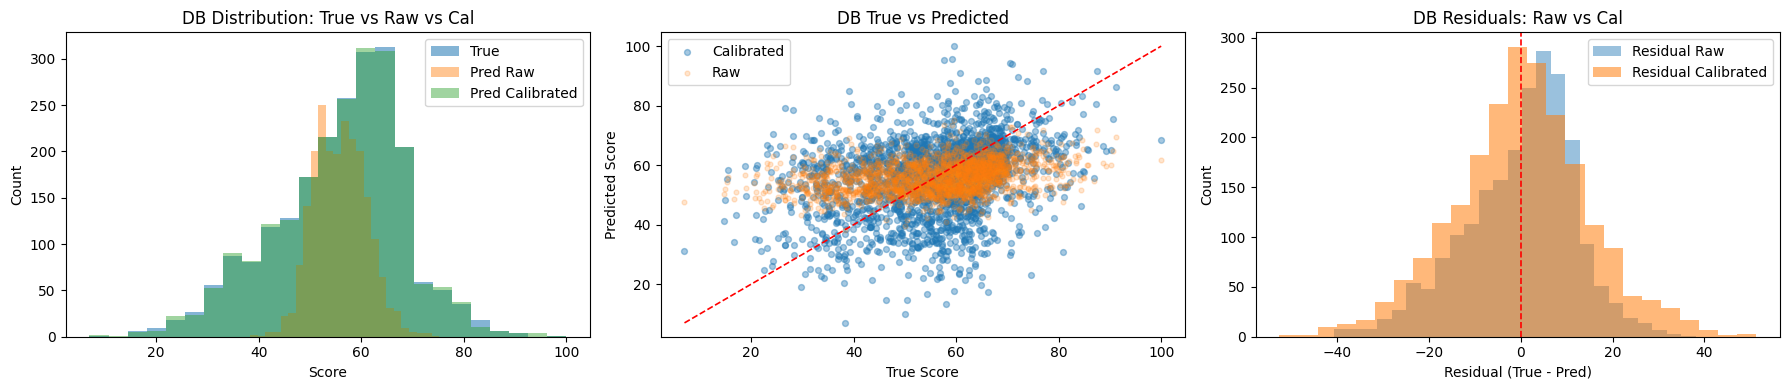

Top 10 predicted players (calibrated) — DB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
2,201500009,Kevin Toliver II,2015,CB,0.9949,75.245094,100.000000,59.6288,Elite Power 4,Multi-Year Starter
2563,201900023,Andrew Booth,2019,CB,0.9891,73.485199,95.733026,59.1700,Elite Power 4,Multi-Year Starter
1234,201700076,Jamyest Williams,2017,CB,0.9638,73.386803,95.494458,57.7077,Elite Power 4,Multi-Year Starter
4,201500020,Kendall Sheffield,2015,CB,0.9900,72.882523,94.271800,70.4117,Elite Power 4,Meaningful P4 Contributor
3223,202000014,Eli Ricks,2020,CB,0.9928,72.757736,93.969247,70.9303,Elite Power 4,Meaningful P4 Contributor
1222,201700025,Richard LeCounte III,2017,S,0.9875,71.787094,91.615866,76.9391,Elite Power 4,Meaningful P4 Contributor
1219,201700017,Shaun Wade,2017,CB,0.9903,71.778885,91.595962,87.5233,Elite Power 4,Elite Power 4
3822,202100018,Kool-Aid McKinstry,2021,CB,0.9906,71.559883,91.064979,60.7975,Elite Power 4,Meaningful G5 Contributor
1220,201700018,JaCoby Stevens,2017,S,0.9901,70.972290,89.640323,72.0796,Elite Power 4,Meaningful P4 Contributor
3823,202100029,Jason Marshall Jr.,2021,CB,0.9854,70.606918,88.754457,65.7934,Elite Power 4,Meaningful G5 Contributor



===== EDGE Visualization Suite (Calibrated) =====


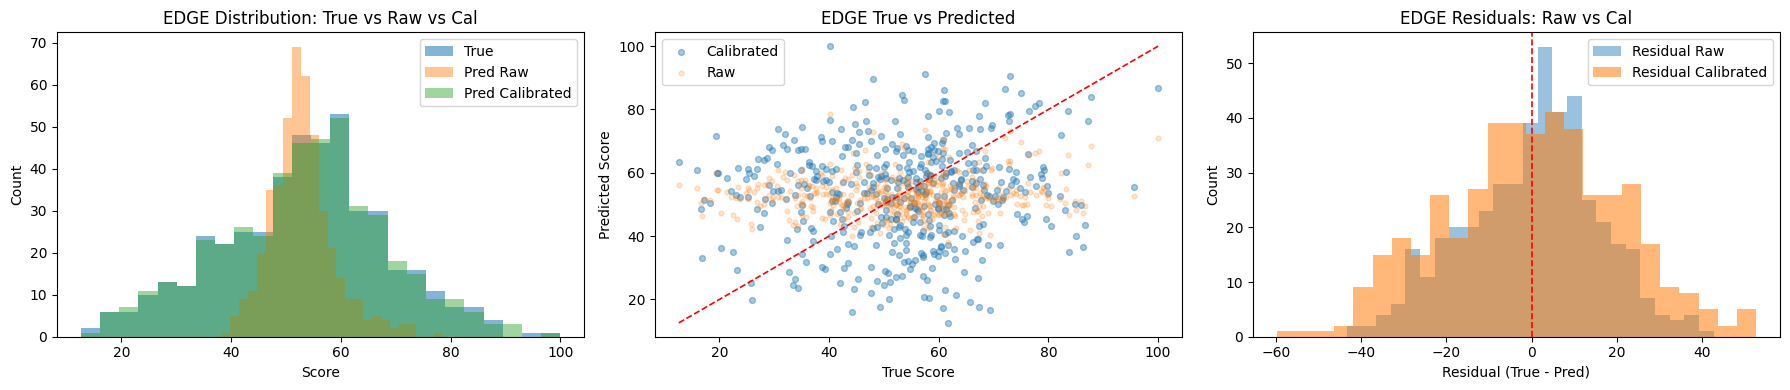

Top 10 predicted players (calibrated) — EDGE


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
6,201500057,Jalen Dalton,2015,WDE,0.9737,78.594513,100.000000,40.0965,Elite Power 4,Single Season Contributor
0,201500003,Byron Cowart,2015,SDE,0.9987,73.652031,91.203959,57.4951,Elite Power 4,Multi-Year Starter
316,201600032,Marlon Davidson,2016,SDE,0.9812,73.349953,90.666356,72.9151,Elite Power 4,Meaningful P4 Contributor
2147,202100059,Keanu Koht,2021,Edge,0.9715,72.790298,89.670350,48.0035,Elite Power 4,Single Season Contributor
677,201700007,Chase Young,2017,WDE,0.9957,71.099220,86.660770,100.0000,Elite Power 4,Elite Power 4
1067,201800003,Xavier Thomas,2018,SDE,0.9988,70.939163,86.427350,72.1023,Elite Power 4,Meaningful P4 Contributor
318,201600041,Shane Simmons,2016,WDE,0.9783,70.692467,86.153454,60.9284,Elite Power 4,Meaningful G5 Contributor
1073,201800066,Ronnie Perkins,2018,WDE,0.9666,69.737175,85.092838,75.0485,Elite Power 4,Meaningful P4 Contributor
2150,202100077,Dylan Brooks,2021,Edge,0.9658,69.249161,84.551018,53.3660,Elite Power 4,Multi-Year Starter
679,201700027,A.J. Epenesa,2017,SDE,0.9868,68.616913,83.849062,87.7959,Elite Power 4,Elite Power 4



===== IDL Visualization Suite (Calibrated) =====


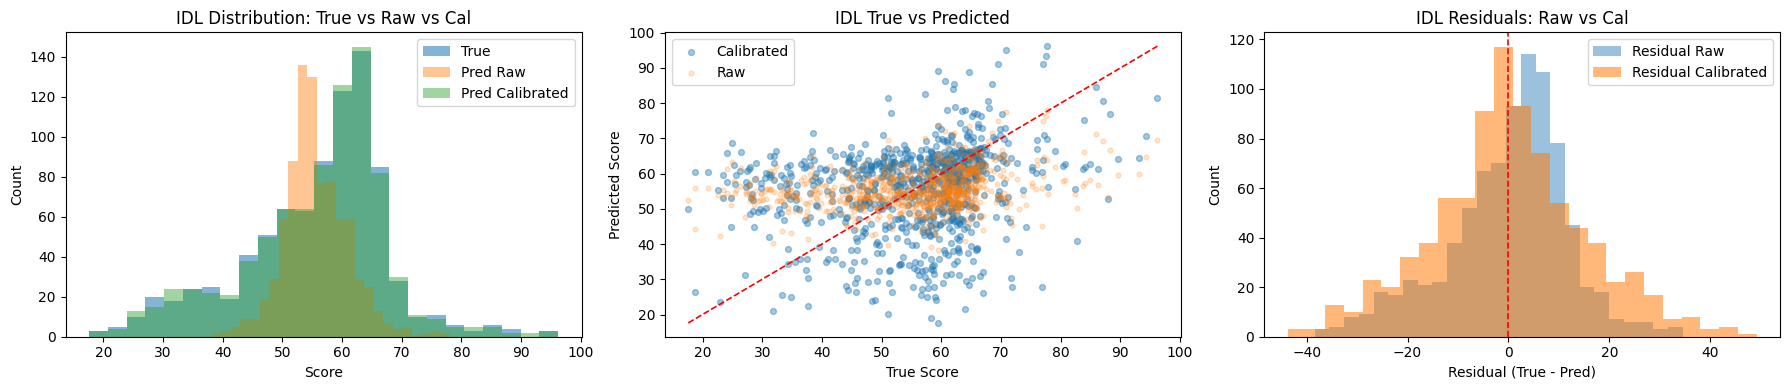

Top 10 predicted players (calibrated) — IDL


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
2,201500013,Terry Beckner Jr.,2015,DT,0.9918,78.104889,96.195500,77.6394,Elite Power 4,Meaningful P4 Contributor
938,201900022,Travon Walker,2019,DT,0.9900,77.415878,95.049149,70.7824,Elite Power 4,Meaningful P4 Contributor
225,201600001,Rashan Gary,2016,DT,1.0000,76.405289,93.367768,77.5369,Elite Power 4,Meaningful P4 Contributor
226,201600002,Dexter Lawrence,2016,DT,0.9992,75.086853,91.174203,77.0945,Elite Power 4,Meaningful P4 Contributor
457,201700006,Marvin Wilson,2017,DT,0.9957,75.022026,91.066346,69.5753,Elite Power 4,Meaningful G5 Contributor
1178,202000008,Jordan Burch,2020,DT,0.9954,73.804123,89.040044,59.5086,Elite Power 4,Multi-Year Starter
936,201900008,Zacch Pickens,2019,DT,0.9945,73.658928,88.798474,64.6111,Elite Power 4,Meaningful G5 Contributor
0,201500001,Trenton Thompson,2015,DT,0.9991,72.183121,86.343080,60.5670,Elite Power 4,Meaningful G5 Contributor
1426,202100011,Leonard Taylor III,2021,DL,0.9938,71.671722,85.492234,68.5564,Elite Power 4,Meaningful G5 Contributor
710,201800020,Taron Vincent,2018,DT,0.9884,71.637802,85.431074,62.2125,Elite Power 4,Meaningful G5 Contributor



===== LB Visualization Suite (Calibrated) =====


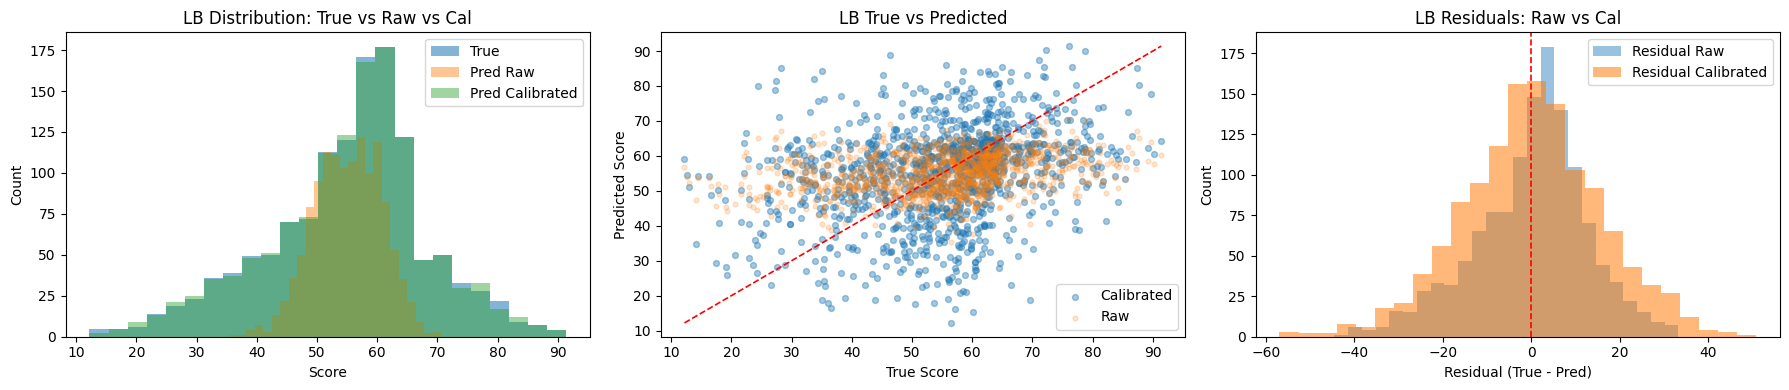

Top 10 predicted players (calibrated) — LB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
2720,202100033,Barrett Carter,2021,LB,0.9835,70.662582,91.397600,76.1622,Elite Power 4,Meaningful P4 Contributor
2278,202000036,Curtis Jacobs,2020,OLB,0.9823,70.008324,90.275629,72.3222,Elite Power 4,Meaningful P4 Contributor
1797,201900025,Owen Pappoe,2019,OLB,0.9878,69.893616,90.078919,78.6829,Elite Power 4,Meaningful P4 Contributor
394,201600011,Mique Juarez,2016,OLB,0.9924,69.116447,88.746173,46.3304,Elite Power 4,Single Season Contributor
1806,201900110,Christian Harris,2019,ILB,0.9506,68.410789,87.536059,71.1471,Elite Power 4,Meaningful P4 Contributor
2279,202000039,Demouy Kennedy,2020,ILB,0.9819,67.512306,85.995273,55.6431,Elite Power 4,Multi-Year Starter
431,201600400,Tyrel Dodson,2016,ILB,0.8824,67.264397,85.570139,71.8752,Elite Power 4,Meaningful P4 Contributor
2281,202000064,Derek Wingo,2020,OLB,0.9704,67.195724,85.452375,64.9812,Elite Power 4,Meaningful G5 Contributor
2722,202100037,Jeremiah Trotter Jr.,2021,LB,0.9818,67.179924,85.425279,76.6444,Elite Power 4,Meaningful P4 Contributor
1796,201900019,Nakobe Dean,2019,ILB,0.9907,67.041985,85.188730,87.4416,Elite Power 4,Elite Power 4



===== OL Visualization Suite (Calibrated) =====


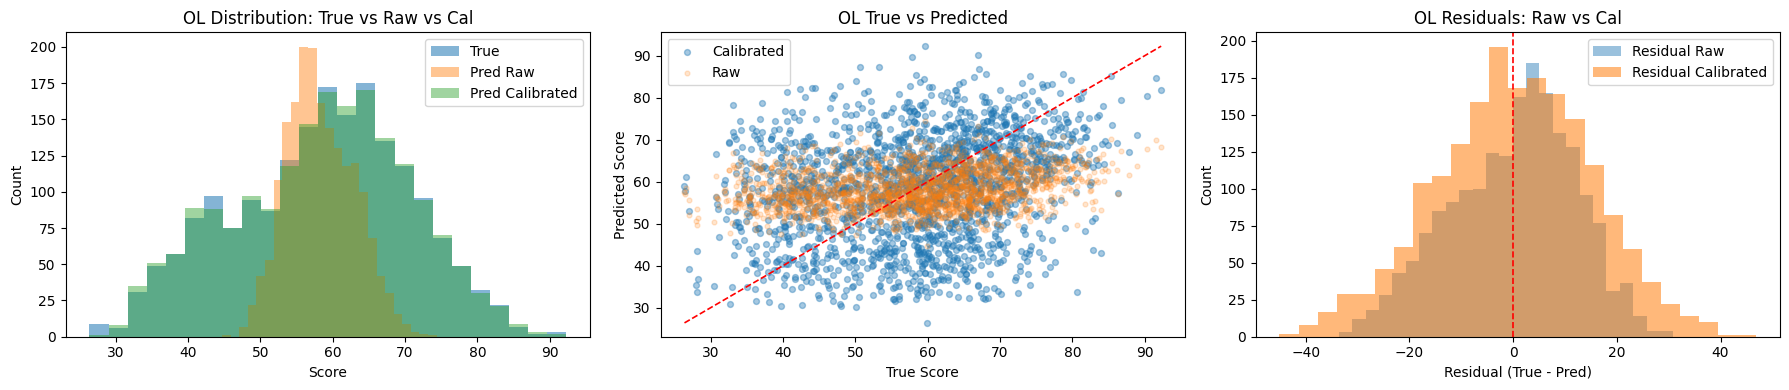

Top 10 predicted players (calibrated) — OL


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
1168,201700016,Isaiah Wilson,2017,OT,0.9904,74.355049,92.248600,59.6724,Elite Power 4,Multi-Year Starter
0,201500002,Martez Ivey,2015,OT,0.9991,73.152657,90.182908,66.9764,Elite Power 4,Meaningful G5 Contributor
1176,201700053,Josh Myers,2017,OG,0.9757,72.787727,89.555965,57.8203,Elite Power 4,Multi-Year Starter
2454,201900552,Justin Britt,2019,OG,0.8815,71.489655,87.325896,53.2500,Elite Power 4,Multi-Year Starter
3590,202100036,Kingsley Suamataia,2021,OT,0.9823,71.480110,87.309499,50.6962,Elite Power 4,Multi-Year Starter
2973,202000038,Tate Ratledge,2020,OT,0.9821,71.182281,86.797834,67.0605,Elite Power 4,Meaningful G5 Contributor
2974,202000048,Turner Corcoran,2020,OT,0.9748,70.562012,85.732220,78.7474,Elite Power 4,Meaningful P4 Contributor
1175,201700048,Austin Deculus,2017,OT,0.9772,70.444244,85.529898,68.0735,Elite Power 4,Meaningful G5 Contributor
1787,201800062,Trey Hill,2018,OG,0.9692,70.322495,85.320733,58.4461,Elite Power 4,Multi-Year Starter
1164,201700004,Alex Leatherwood,2017,OT,0.9981,70.243851,85.185625,85.2938,Elite Power 4,Elite Power 4



===== QB Visualization Suite (Calibrated) =====


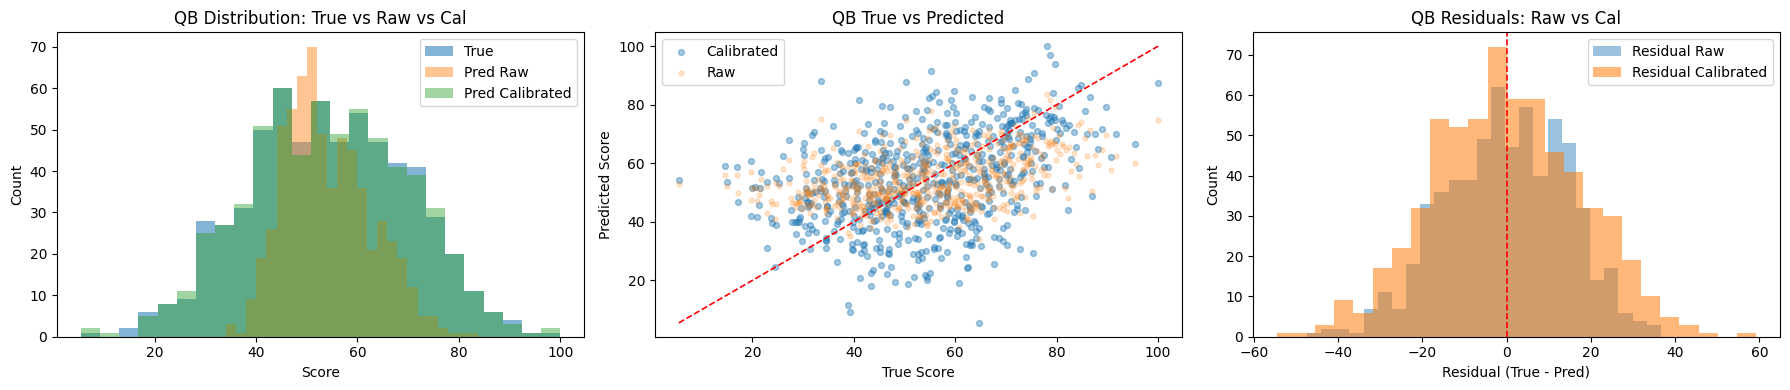

Top 10 predicted players (calibrated) — QB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
494,201700032,Tua Tagovailoa,2017,DUAL,0.9843,83.777779,100.000000,78.0845,Elite Power 4,Meaningful P4 Contributor
1269,202000002,Bryce Young,2020,DUAL,0.9994,81.675835,97.109508,78.6455,Elite Power 4,Meaningful P4 Contributor
2,201500034,Kyler Murray,2015,DUAL,0.9854,79.371529,93.940738,79.5764,Elite Power 4,Meaningful P4 Contributor
493,201700030,Hunter Johnson,2017,PRO,0.9854,77.694466,91.634522,55.2999,Elite Power 4,Multi-Year Starter
217,201600004,Shea Patterson,2016,PRO,0.9981,77.118317,90.842230,75.5663,Elite Power 4,Meaningful P4 Contributor
1004,201900093,Sam Howell,2019,DUAL,0.9582,75.602554,88.757827,74.2916,Elite Power 4,Meaningful P4 Contributor
1543,202100012,Sam Huard,2021,QB,0.9935,75.106667,88.075906,33.4934,Elite Power 4,Partial Season Contributor
497,201700105,Jack Sears,2017,PRO,0.9516,74.914932,87.823881,50.2394,Elite Power 4,Multi-Year Starter
1000,201900033,Bo Nix,2019,DUAL,0.9856,74.716560,87.567814,100.0000,Elite Power 4,Elite Power 4
7,201500073,Jake Browning,2015,PRO,0.9633,74.042557,86.697781,84.8014,Elite Power 4,Elite Power 4



===== RB Visualization Suite (Calibrated) =====


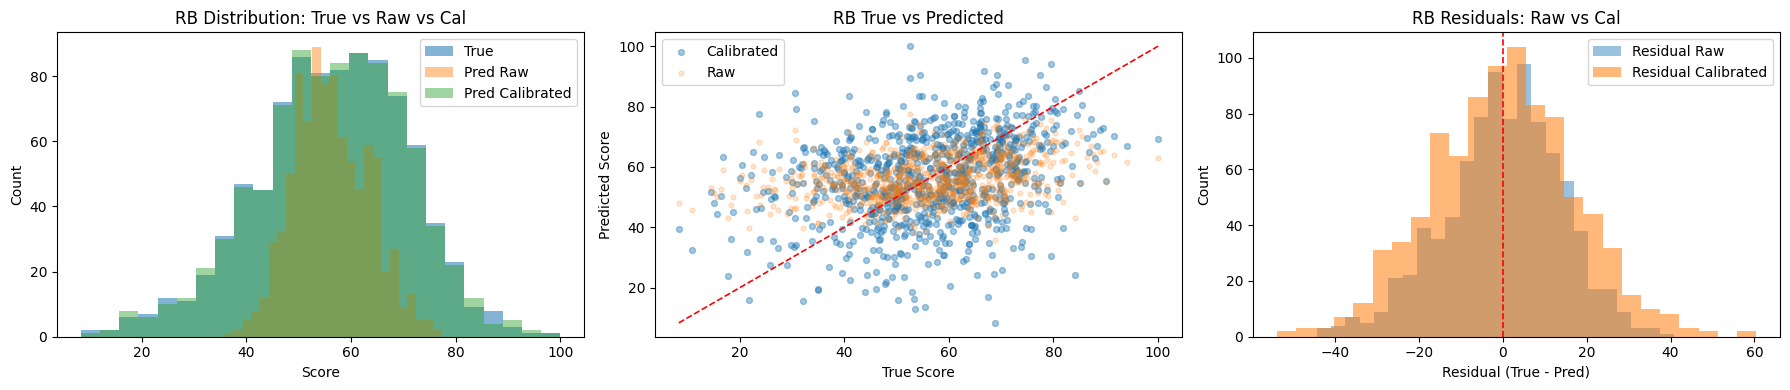

Top 10 predicted players (calibrated) — RB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
1347,201900182,Sampson James,2019,RB,0.9255,77.422722,100.000000,52.6541,Elite Power 4,Multi-Year Starter
1027,201800009,Zamir White,2018,RB,0.9957,75.910210,95.331652,74.5233,Elite Power 4,Meaningful P4 Contributor
1659,202000040,Tank Bigsby,2020,RB,0.9814,75.504074,94.078121,79.4569,Elite Power 4,Meaningful P4 Contributor
1344,201900139,Tyrion Davis-Price,2019,RB,0.9398,74.719872,91.657690,66.7838,Elite Power 4,Meaningful G5 Contributor
350,201600106,Kareem Walker,2016,RB,0.9505,74.353203,90.525973,54.4440,Elite Power 4,Multi-Year Starter
1664,202000076,Jahmyr Gibbs,2020,RB,0.9651,74.332848,90.463147,69.1964,Elite Power 4,Meaningful G5 Contributor
684,201700003,Cam Akers,2017,RB,0.9983,74.284325,90.313381,77.3351,Elite Power 4,Meaningful P4 Contributor
1336,201900006,Trey Sanders,2019,RB,0.9963,73.980278,89.374946,52.5606,Elite Power 4,Multi-Year Starter
1660,202000043,MarShawn Lloyd,2020,RB,0.9778,73.407333,87.606560,69.0926,Elite Power 4,Meaningful G5 Contributor
685,201700020,Stephen Carr,2017,RB,0.9888,73.242607,87.114270,71.2199,Elite Power 4,Meaningful P4 Contributor



===== SPEC Visualization Suite (Calibrated) =====


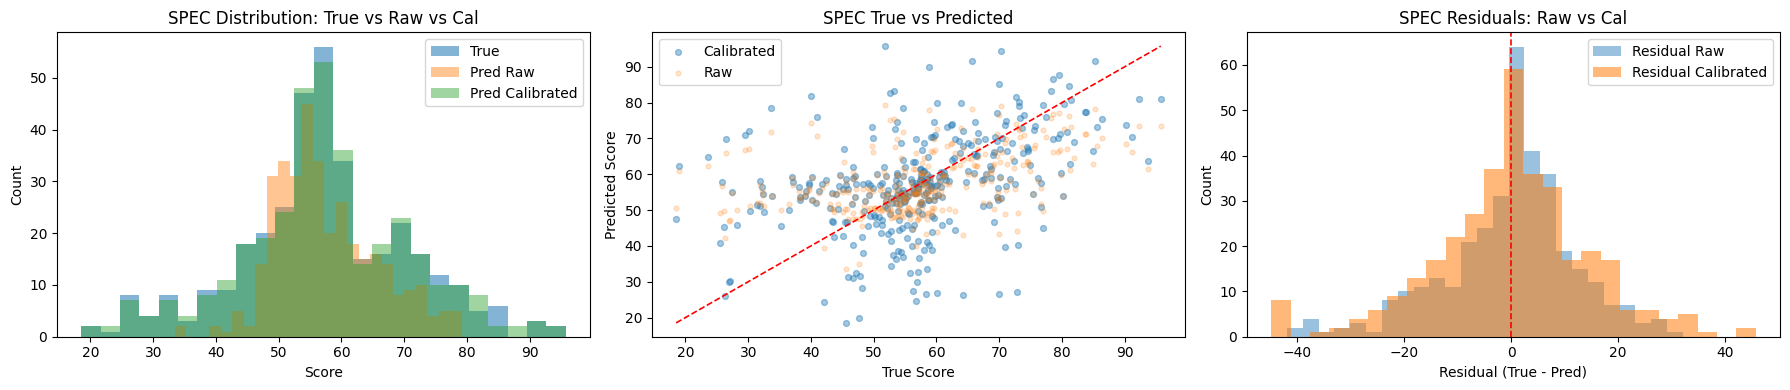

Top 10 predicted players (calibrated) — SPEC


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
159,201701524,Cole Hahn,2017,K,0.8250,79.188095,95.738300,51.8708,Elite Power 4,Multi-Year Starter
92,201601616,Connor Culp,2016,K,0.8222,78.921791,94.505445,70.3064,Elite Power 4,Meaningful P4 Contributor
0,201500829,Justin Yoon,2015,K,0.8550,78.296707,91.611619,85.2725,Elite Power 4,Elite Power 4
470,202101887,Joe McFadden,2021,K,0.8256,78.280975,91.538788,65.5976,Elite Power 4,Meaningful G5 Contributor
90,201601579,Alex Barbir,2016,K,0.8233,77.896835,90.003206,58.7569,Elite Power 4,Multi-Year Starter
76,201600818,JJ Molson,2016,K,0.8533,77.211823,87.697858,79.5987,Elite Power 4,Meaningful P4 Contributor
466,202101533,Cam Little,2021,K,0.8378,76.907974,86.675284,78.5190,Elite Power 4,Meaningful P4 Contributor
396,202001718,Jack Olsen,2020,K,0.8344,76.491150,85.272500,70.0220,Elite Power 4,Meaningful P4 Contributor
469,202101669,Andres Borregales,2021,K,0.8333,76.148331,84.535934,81.0426,Elite Power 4,Elite Power 4
153,201701278,Brandon Ruiz,2017,K,0.8350,75.557510,83.266523,78.3001,Elite Power 4,Meaningful P4 Contributor



===== TE Visualization Suite (Calibrated) =====


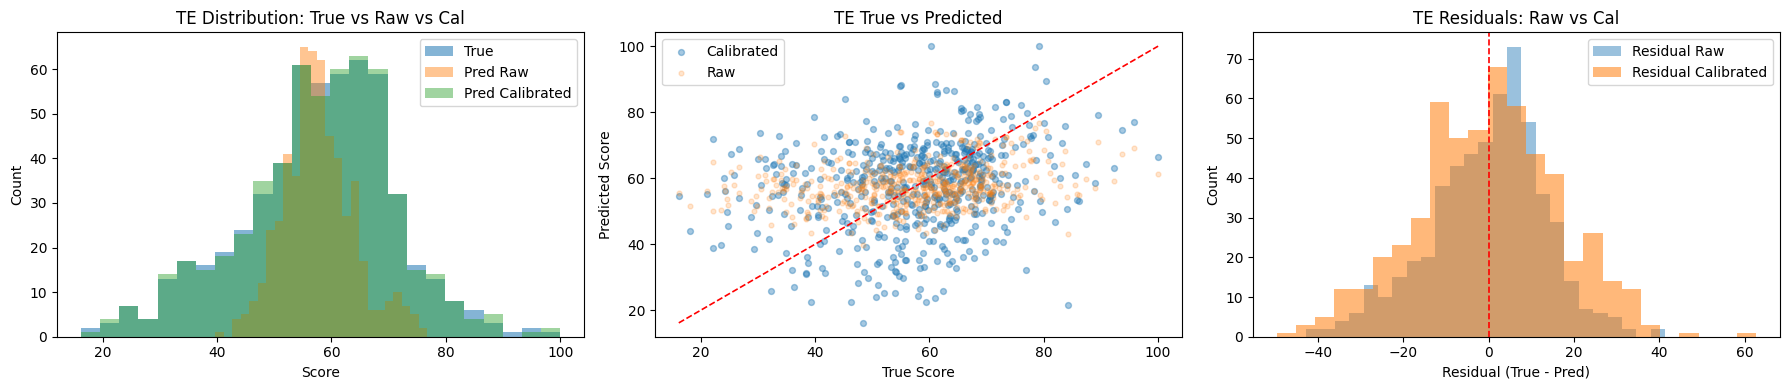

Top 10 predicted players (calibrated) — TE


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
493,201800150,Zack Kuntz,2018,TE,0.9377,76.701767,100.000000,60.3421,Elite Power 4,Meaningful G5 Contributor
490,201800033,Brevin Jordan,2018,TE,0.9820,76.698204,99.984704,79.2400,Elite Power 4,Meaningful P4 Contributor
147,201600038,Kaden Smith,2016,TE,0.9801,75.204010,93.569965,78.4677,Elite Power 4,Meaningful P4 Contributor
980,202100130,Michael Trigg,2021,TE,0.9402,74.235573,89.412357,80.3826,Elite Power 4,Elite Power 4
652,201900132,Hudson Henry,2019,TE,0.9422,74.056259,88.642544,61.0064,Elite Power 4,Meaningful G5 Contributor
150,201600150,Naseir Upshur,2016,TE,0.9341,73.933075,88.113701,54.9885,Elite Power 4,Multi-Year Starter
149,201600120,Jake Hausmann,2016,TE,0.9439,73.901970,87.989959,54.8544,Elite Power 4,Multi-Year Starter
655,201900218,Jude Wolfe,2019,TE,0.9147,73.527931,86.645926,62.8456,Elite Power 4,Meaningful G5 Contributor
311,201700082,Cole Kmet,2017,TE,0.9609,73.505745,86.566204,64.2917,Elite Power 4,Meaningful G5 Contributor
982,202100201,Elijah Arroyo,2021,TE,0.9212,73.369255,86.075756,61.3667,Elite Power 4,Meaningful G5 Contributor



===== WR Visualization Suite (Calibrated) =====


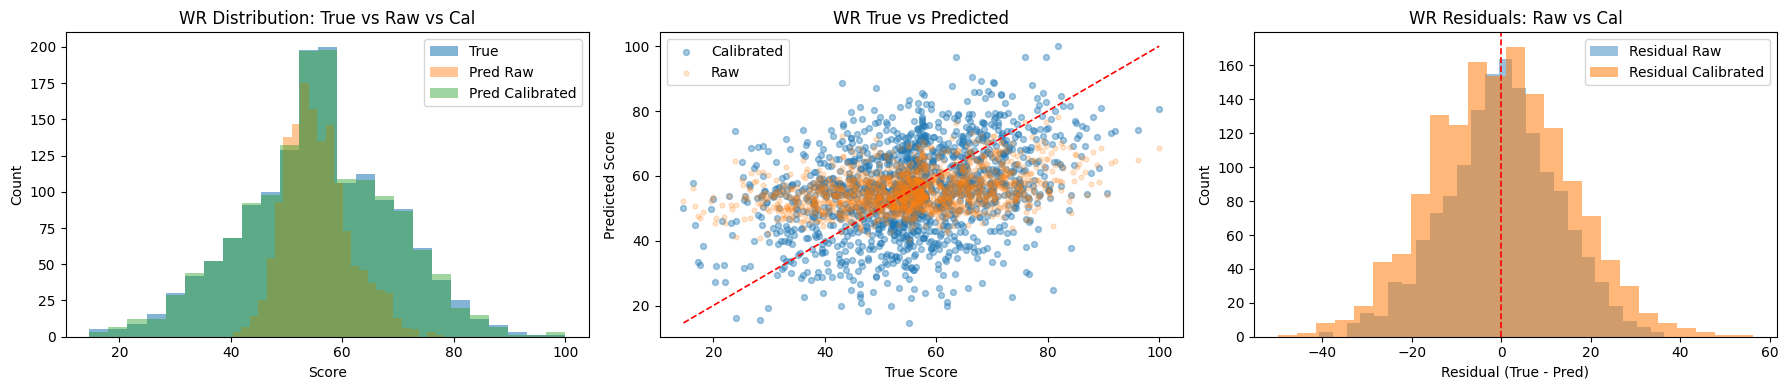

Top 10 predicted players (calibrated) — WR


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
3,201500025,Christian Kirk,2015,WR,0.9891,78.256119,100.000000,81.8121,Elite Power 4,Elite Power 4
1,201500018,Deon Cain,2015,WR,0.9906,76.562866,96.810155,79.6241,Elite Power 4,Meaningful P4 Contributor
1532,201800011,Amon-Ra St. Brown,2018,WR,0.9948,76.497726,96.687441,75.9450,Elite Power 4,Meaningful P4 Contributor
972,201700040,Jeff Thomas,2017,WR,0.9807,76.415733,96.532977,63.4706,Elite Power 4,Meaningful G5 Contributor
410,201600034,Tyrie Cleveland,2016,WR,0.9810,73.228699,90.529061,66.4168,Elite Power 4,Meaningful G5 Contributor
4,201500029,Tyron Johnson,2015,WR,0.9878,72.471779,89.103132,68.1091,Elite Power 4,Meaningful G5 Contributor
408,201600013,Demetris Robertson,2016,WR,0.9905,72.424873,89.014769,70.1890,Elite Power 4,Meaningful P4 Contributor
971,201700031,Joseph Lewis,2017,WR,0.9843,72.295723,88.771468,43.0929,Elite Power 4,Single Season Contributor
978,201700075,Henry Ruggs III,2017,WR,0.9640,72.284012,88.749406,70.4274,Elite Power 4,Meaningful P4 Contributor
409,201600030,Tyler Vaughns,2016,WR,0.9816,71.929222,88.081033,77.1957,Elite Power 4,Meaningful P4 Contributor


In [8]:
# Per-position visualization suite + top-10 predicted players (raw vs calibrated)
import matplotlib.pyplot as plt

for pos in FINAL_POSITION_GROUPS:
    pred_df = prediction_tables.get(pos)
    if pred_df is None or pred_df.empty:
        print(f"\n[{pos}] No prediction table available.")
        continue

    vis_df = pred_df.copy()
    vis_df["y_true_score"] = pd.to_numeric(vis_df.get("y_true_score", pd.NA), errors="coerce")
    vis_df["y_pred_score_oof_raw"] = pd.to_numeric(
        vis_df.get("y_pred_score_oof_raw", vis_df.get("y_pred_score_oof", pd.NA)), errors="coerce"
    )
    vis_df["y_pred_score_oof_calibrated"] = pd.to_numeric(
        vis_df.get("y_pred_score_oof_calibrated", vis_df.get("y_pred_score_oof", pd.NA)), errors="coerce"
    )
    vis_df["residual_raw"] = vis_df["y_true_score"] - vis_df["y_pred_score_oof_raw"]
    vis_df["residual_calibrated"] = vis_df["y_true_score"] - vis_df["y_pred_score_oof_calibrated"]
    vis_df = vis_df.dropna(subset=["y_true_score", "y_pred_score_oof_calibrated"]).copy()

    if vis_df.empty:
        print(f"\n[{pos}] No valid numeric prediction rows for visualization.")
        continue

    print(f"\n===== {pos} Visualization Suite (Calibrated) =====")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(vis_df["y_true_score"], bins=25, alpha=0.55, label="True")
    if vis_df["y_pred_score_oof_raw"].notna().any():
        axes[0].hist(vis_df["y_pred_score_oof_raw"], bins=25, alpha=0.45, label="Pred Raw")
    axes[0].hist(vis_df["y_pred_score_oof_calibrated"], bins=25, alpha=0.45, label="Pred Calibrated")
    axes[0].set_title(f"{pos} Distribution: True vs Raw vs Cal")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    axes[1].scatter(vis_df["y_true_score"], vis_df["y_pred_score_oof_calibrated"], alpha=0.4, s=18, label="Calibrated")
    if vis_df["y_pred_score_oof_raw"].notna().any():
        axes[1].scatter(vis_df["y_true_score"], vis_df["y_pred_score_oof_raw"], alpha=0.2, s=12, label="Raw")
    line_min = min(
        vis_df["y_true_score"].min(),
        vis_df["y_pred_score_oof_calibrated"].min(),
        vis_df["y_pred_score_oof_raw"].min() if vis_df["y_pred_score_oof_raw"].notna().any() else vis_df["y_pred_score_oof_calibrated"].min()
    )
    line_max = max(
        vis_df["y_true_score"].max(),
        vis_df["y_pred_score_oof_calibrated"].max(),
        vis_df["y_pred_score_oof_raw"].max() if vis_df["y_pred_score_oof_raw"].notna().any() else vis_df["y_pred_score_oof_calibrated"].max()
    )
    axes[1].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1.2)
    axes[1].set_title(f"{pos} True vs Predicted")
    axes[1].set_xlabel("True Score")
    axes[1].set_ylabel("Predicted Score")
    axes[1].legend()

    if vis_df["residual_raw"].notna().any():
        axes[2].hist(vis_df["residual_raw"], bins=25, alpha=0.45, label="Residual Raw")
    axes[2].hist(vis_df["residual_calibrated"], bins=25, alpha=0.55, label="Residual Calibrated")
    axes[2].axvline(0, color="red", linestyle="--", linewidth=1.2)
    axes[2].set_title(f"{pos} Residuals: Raw vs Cal")
    axes[2].set_xlabel("Residual (True - Pred)")
    axes[2].set_ylabel("Count")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    top_cols = [
        col for col in [
            "player_id", "name", "year", "position", "rating",
            "y_pred_score_oof_raw", "y_pred_score_oof_calibrated", "y_true_score", "y_pred_tier", "y_true_tier"
        ] if col in vis_df.columns
    ]

    top10 = vis_df.sort_values("y_pred_score_oof_calibrated", ascending=False).head(10)
    print(f"Top 10 predicted players (calibrated) — {pos}")
    display(top10[top_cols])

In [9]:
import pandas as pd
import numpy as np

# 1. Combine all OOF predictions into a single Master DataFrame
all_oof_df = pd.concat(prediction_tables.values(), ignore_index=True)

# Ensure columns are numeric
all_oof_df['rating'] = pd.to_numeric(all_oof_df['rating'], errors='coerce')
all_oof_df['y_true_score'] = pd.to_numeric(all_oof_df['y_true_score'], errors='coerce')
# You can use calibrated or raw here. Raw is fine for rank correlation.
all_oof_df['y_pred'] = pd.to_numeric(all_oof_df['y_pred_score_oof_raw'], errors='coerce')

# Filter out records where we don't have all 3 pieces of data
eval_df = all_oof_df.dropna(subset=['rating', 'y_true_score', 'y_pred']).copy()

# ==========================================
# 1. CORRELATION ANALYSIS (GLOBAL & POSITION)
# ==========================================
print("--- RANK CORRELATION (SPEARMAN) ---")
print("How well did each system rank players from best to worst?\n")

global_247_rho = eval_df['rating'].corr(eval_df['y_true_score'], method='spearman')
global_model_rho = eval_df['y_pred'].corr(eval_df['y_true_score'], method='spearman')

print(f"GLOBAL 247 Rating Correlation:   {global_247_rho:.4f}")
print(f"GLOBAL XGBoost Model Correlation:{global_model_rho:.4f}")
print(f"Edge: {'Model' if global_model_rho > global_247_rho else '247Sports'} by {(global_model_rho - global_247_rho):.4f}\n")

# Per Position Breakdown
pos_records = []
for pos, group in eval_df.groupby('position_group'):
    pos_247_rho = group['rating'].corr(group['y_true_score'], method='spearman')
    pos_model_rho = group['y_pred'].corr(group['y_true_score'], method='spearman')
    
    pos_records.append({
        'Position': pos,
        'N_Players': len(group),
        '247_Spearman': round(pos_247_rho, 4),
        'Model_Spearman': round(pos_model_rho, 4),
        'Model_Advantage': round(pos_model_rho - pos_247_rho, 4)
    })

df_pos_eval = pd.DataFrame(pos_records).sort_values('Model_Advantage', ascending=False)
display(df_pos_eval)

# ==========================================
# 2. THE "TOP PROSPECT" SIMULATION
# ==========================================
print("\n--- TOP PROSPECT EVALUATION ---")
print("If you only recruited the Top 10% of players based on each system,")
print("whose recruiting class actually produced more value on the field?\n")

top_10_percent_cutoff = int(len(eval_df) * 0.10)

# Sort by 247 Rating to simulate 247's "Top Class"
top_247_class = eval_df.sort_values('rating', ascending=False).head(top_10_percent_cutoff)

# Sort by Model Prediction to simulate the Model's "Top Class"
top_model_class = eval_df.sort_values('y_pred', ascending=False).head(top_10_percent_cutoff)

avg_true_score_247 = top_247_class['y_true_score'].mean()
avg_true_score_model = top_model_class['y_true_score'].mean()

print(f"Average True Score of 247's Top {top_10_percent_cutoff} players:    {avg_true_score_247:.2f}")
print(f"Average True Score of Model's Top {top_10_percent_cutoff} players:  {avg_true_score_model:.2f}")

if avg_true_score_model > avg_true_score_247:
    diff = avg_true_score_model - avg_true_score_247
    print(f"\n✅ The XGBoost Model successfully identified better elite talent than 247Sports (+{diff:.2f} score advantage per player).")
else:
    diff = avg_true_score_247 - avg_true_score_model
    print(f"\n❌ 247Sports is still better at identifying elite talent than the Model (+{diff:.2f} score advantage per player).")
    


--- RANK CORRELATION (SPEARMAN) ---
How well did each system rank players from best to worst?

GLOBAL 247 Rating Correlation:   0.3206
GLOBAL XGBoost Model Correlation:0.3216
Edge: Model by 0.0009



,Position,N_Players,247_Spearman,Model_Spearman,Model_Advantage
7,SPEC,351,0.3609,0.4511,0.0902
3,LB,1291,0.3387,0.3274,-0.0113
4,OL,1886,0.2837,0.2592,-0.0245
0,DB,2176,0.3648,0.3397,-0.0251
9,WR,1495,0.3570,0.3279,-0.0291
5,QB,629,0.4464,0.3885,-0.0579
2,IDL,853,0.3519,0.2795,-0.0724
6,RB,888,0.3898,0.3078,-0.0820
1,EDGE,453,0.1668,0.0569,-0.1099
8,TE,556,0.3700,0.2282,-0.1418



--- TOP PROSPECT EVALUATION ---
If you only recruited the Top 10% of players based on each system,
whose recruiting class actually produced more value on the field?

Average True Score of 247's Top 1057 players:    64.87
Average True Score of Model's Top 1057 players:  64.55

❌ 247Sports is still better at identifying elite talent than the Model (+0.33 score advantage per player).


In [10]:
import pandas as pd

# 1. Combine all OOF prediction dataframes into one
all_oof_df = pd.concat(prediction_tables.values(), ignore_index=True)

# 2. Extract and clean the two columns we want to compare
# Using the calibrated score, but you can swap to 'y_pred_score_oof_raw' if you prefer
rating_col = pd.to_numeric(all_oof_df['rating'], errors='coerce')
pred_col = pd.to_numeric(all_oof_df['y_pred_score_oof_calibrated'], errors='coerce')

# 3. Create a clean subset dropping any rows missing either value
corr_df = pd.DataFrame({
    '247_Rating': rating_col, 
    'Model_Prediction': pred_col
}).dropna()

# 4. Calculate Correlations
pearson_corr = corr_df['247_Rating'].corr(corr_df['Model_Prediction'], method='pearson')
spearman_corr = corr_df['247_Rating'].corr(corr_df['Model_Prediction'], method='spearman')

print("--- Agreement: 247Sports Rating vs. XGBoost Prediction ---")
print(f"Sample Size: {len(corr_df)} players\n")
print(f"Pearson Correlation (Linear): {pearson_corr:.4f}")
print(f"Spearman Correlation (Rank):  {spearman_corr:.4f}")

# Optional: Quick Positional Breakdown
print("\n--- Spearman Correlation by Position ---")
for pos, group in all_oof_df.dropna(subset=['rating', 'y_pred_score_oof_calibrated']).groupby('position_group'):
    pos_corr = pd.to_numeric(group['rating']).corr(pd.to_numeric(group['y_pred_score_oof_calibrated']), method='spearman')
    print(f"{pos.ljust(5)}: {pos_corr:.4f}")

--- Agreement: 247Sports Rating vs. XGBoost Prediction ---
Sample Size: 10578 players

Pearson Correlation (Linear): 0.7097
Spearman Correlation (Rank):  0.7326

--- Spearman Correlation by Position ---
DB   : 0.8579
EDGE : 0.3939
IDL  : 0.6900
LB   : 0.7657
OL   : 0.7395
QB   : 0.8499
RB   : 0.7945
SPEC : 0.5892
TE   : 0.7822
WR   : 0.8058


In [11]:
# Quick artifact inventory
artifacts = sorted([p for p in MODEL_DIR.rglob("*") if p.is_file()])
print(f"Total artifacts in {MODEL_DIR}: {len(artifacts)}")
for p in artifacts:
    print(p.relative_to(MODEL_DIR).as_posix())

Total artifacts in x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional: 45
artifacts/DB_xgb_regressor.joblib
artifacts/EDGE_xgb_regressor.joblib
artifacts/IDL_xgb_regressor.joblib
artifacts/LB_xgb_regressor.joblib
artifacts/OL_xgb_regressor.joblib
artifacts/QB_xgb_regressor.joblib
artifacts/RB_xgb_regressor.joblib
artifacts/SPEC_xgb_regressor.joblib
artifacts/TE_xgb_regressor.joblib
artifacts/WR_xgb_regressor.joblib
diagnostics/DB_cv_fold_metrics.csv
diagnostics/EDGE_cv_fold_metrics.csv
diagnostics/IDL_cv_fold_metrics.csv
diagnostics/LB_cv_fold_metrics.csv
diagnostics/OL_cv_fold_metrics.csv
diagnostics/QB_cv_fold_metrics.csv
diagnostics/RB_cv_fold_metrics.csv
diagnostics/SPEC_cv_fold_metrics.csv
diagnostics/TE_cv_fold_metrics.csv
diagnostics/WR_cv_fold_metrics.csv
regression/DB_future_predictions_2022_2028.csv
regression/DB_oof_predictions.csv
regression/EDGE_future_predictions_2022_2028.csv
regression/EDGE_oof_p

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    log_loss, roc_auc_score, accuracy_score, f1_score, brier_score_loss
 )
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.pipeline import Pipeline

param_space_cls = {
    "model__n_estimators": [150, 250, 400],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__subsample": [0.75, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda": [1.0, 2.0, 4.0],
}

class_model_rows = []
class_feature_rows = []
class_prediction_tables = {}
class_future_prediction_tables = {}
class_feature_inventory_rows = []

for pos in FINAL_POSITION_GROUPS:
    df = datasets[pos].copy()

    target_numeric = pd.to_numeric(df.get("target_career_score_0_100", pd.NA), errors="coerce")
    valid_target_mask = target_numeric.notna()
    df = df[valid_target_mask].copy()
    target_numeric = pd.to_numeric(df["target_career_score_0_100"], errors="coerce")

    if len(df) < 80:
        print(f"Skipping {pos}: not enough rows for 5-fold CV ({len(df)})")
        continue

    candidate_cols = select_model_feature_candidates(df)
    numeric_cols, categorical_cols, dropped_cols = infer_column_types(df, candidate_cols)
    model_feature_cols = numeric_cols + categorical_cols

    if len(model_feature_cols) < 5:
        print(f"Skipping {pos}: too few modeled features ({len(model_feature_cols)})")
        continue

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    X_all = df[model_feature_cols].copy()
    df_valid = df.loc[X_all.index].copy()

    preprocessor = build_preprocessor(numeric_cols, categorical_cols)
    sampled_params = list(ParameterSampler(param_space_cls, n_iter=N_TUNING_ITER, random_state=SEED))

    target_results = {}
    all_fold_rows = []
    model_paths_by_target = {}

    for target_cfg in CLASS_TARGETS:
        target_id = target_cfg["id"]
        threshold = target_cfg["threshold"]

        y_all_target = (target_numeric >= threshold).astype(int)
        class_counts = y_all_target.value_counts(dropna=False)
        min_class_count = int(class_counts.min()) if not class_counts.empty else 0

        use_modeling = y_all_target.nunique() >= 2 and min_class_count >= 2

        best_logloss = np.nan
        best_params = None
        oof_pred_proba_raw = pd.Series(index=X_all.index, dtype=float)
        final_pipe = None
        used_n_folds = np.nan

        if use_modeling:
            n_folds_target = int(min(N_FOLDS, min_class_count))
            if n_folds_target >= 2:
                used_n_folds = n_folds_target
                skf = StratifiedKFold(n_splits=n_folds_target, shuffle=True, random_state=SEED)

                best_logloss = float("inf")
                for params in sampled_params:
                    fold_loglosses = []
                    for train_idx, val_idx in skf.split(X_all, y_all_target):
                        X_train, y_train = X_all.iloc[train_idx], y_all_target.iloc[train_idx]
                        X_val, y_val = X_all.iloc[val_idx], y_all_target.iloc[val_idx]

                        pipe = Pipeline(steps=[
                            ("prep", preprocessor),
                            ("model", XGBClassifier(
                                objective="binary:logistic",
                                eval_metric="logloss",
                                tree_method=XGB_TREE_METHOD,
                                device=XGB_DEVICE,
                                random_state=SEED,
                                n_jobs=-1,
                            )),
                        ])
                        pipe.set_params(**params)
                        pipe.fit(X_train, y_train)
                        val_pred_proba = np.clip(pipe.predict_proba(X_val)[:, 1], 1e-6, 1 - 1e-6)
                        fold_loglosses.append(log_loss(y_val, val_pred_proba))

                    mean_fold_logloss = float(np.mean(fold_loglosses))
                    if mean_fold_logloss < best_logloss:
                        best_logloss = mean_fold_logloss
                        best_params = params

                for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all_target), start=1):
                    X_train, y_train = X_all.iloc[train_idx], y_all_target.iloc[train_idx]
                    X_val, y_val = X_all.iloc[val_idx], y_all_target.iloc[val_idx]

                    fold_pipe = Pipeline(steps=[
                        ("prep", preprocessor),
                        ("model", XGBClassifier(
                            objective="binary:logistic",
                            eval_metric="logloss",
                            tree_method=XGB_TREE_METHOD,
                            device=XGB_DEVICE,
                            random_state=SEED,
                            n_jobs=-1,
                        )),
                    ])
                    if best_params:
                        fold_pipe.set_params(**best_params)

                    fold_pipe.fit(X_train, y_train)
                    val_pred_proba = np.clip(fold_pipe.predict_proba(X_val)[:, 1], 1e-6, 1 - 1e-6)
                    val_pred_class = (val_pred_proba >= 0.5).astype(int)
                    oof_pred_proba_raw.iloc[val_idx] = val_pred_proba

                    fold_auc = roc_auc_score(y_val, val_pred_proba) if y_val.nunique() > 1 else np.nan
                    all_fold_rows.append({
                        "position": pos,
                        "target_id": target_id,
                        "target_threshold": threshold,
                        "fold": fold_id,
                        "rows_val": len(val_idx),
                        "fold_accuracy": float(accuracy_score(y_val, val_pred_class)),
                        "fold_roc_auc": float(fold_auc) if pd.notna(fold_auc) else np.nan,
                        "fold_f1": float(f1_score(y_val, val_pred_class, zero_division=0)),
                        "fold_logloss": float(log_loss(y_val, val_pred_proba)),
                        "fold_brier": float(brier_score_loss(y_val, val_pred_proba)),
                    })

                final_pipe = Pipeline(steps=[
                    ("prep", preprocessor),
                    ("model", XGBClassifier(
                        objective="binary:logistic",
                        eval_metric="logloss",
                        tree_method=XGB_TREE_METHOD,
                        device=XGB_DEVICE,
                        random_state=SEED,
                        n_jobs=-1,
                    )),
                ])
                if best_params:
                    final_pipe.set_params(**best_params)
                final_pipe.fit(X_all, y_all_target)

        if final_pipe is None:
            base_prob = float(y_all_target.mean())
            oof_pred_proba_raw.loc[:] = base_prob
            all_fold_rows.append({
                "position": pos,
                "target_id": target_id,
                "target_threshold": threshold,
                "fold": np.nan,
                "rows_val": len(X_all),
                "fold_accuracy": float(np.mean((base_prob >= 0.5) == y_all_target.values)),
                "fold_roc_auc": np.nan,
                "fold_f1": float(f1_score(y_all_target, (base_prob >= 0.5) * np.ones(len(y_all_target), dtype=int), zero_division=0)),
                "fold_logloss": float(log_loss(y_all_target, np.clip(np.repeat(base_prob, len(y_all_target)), 1e-6, 1 - 1e-6))),
                "fold_brier": float(brier_score_loss(y_all_target, np.repeat(base_prob, len(y_all_target)))),
            })

        oof_pred_class_raw = (oof_pred_proba_raw >= 0.5).astype(int)
        oof_auc_raw = roc_auc_score(y_all_target, oof_pred_proba_raw) if y_all_target.nunique() > 1 else np.nan

        oof_metrics = {
            "oof_logloss_raw": float(log_loss(y_all_target, np.clip(oof_pred_proba_raw, 1e-6, 1 - 1e-6))),
            "oof_brier_raw": float(brier_score_loss(y_all_target, oof_pred_proba_raw)),
            "oof_accuracy_raw": float(accuracy_score(y_all_target, oof_pred_class_raw)),
            "oof_f1_raw": float(f1_score(y_all_target, oof_pred_class_raw, zero_division=0)),
            "oof_auc_raw": float(oof_auc_raw) if pd.notna(oof_auc_raw) else np.nan,
        }

        model_path_target = ARTIFACTS_DIR / f"{pos}_xgb_classifier_{target_id}.joblib"
        joblib.dump({
            "position": pos,
            "pipeline": final_pipe,
            "feature_columns": model_feature_cols,
            "numeric_cols": numeric_cols,
            "categorical_cols": categorical_cols,
            "best_params": best_params,
            "cv": {
                "n_folds": int(used_n_folds) if pd.notna(used_n_folds) else None,
                "strategy": "StratifiedKFold" if pd.notna(used_n_folds) else "constant_baseline"
            },
            "target": f"target_career_score_0_100 >= {int(threshold)}",
            "target_id": target_id,
            "class_1_ratio": float(y_all_target.mean()),
            "future_year_window": {"min": PREDICT_YEAR_MIN, "max": PREDICT_YEAR_MAX},
        }, model_path_target)

        model_paths_by_target[target_id] = str(model_path_target)

        target_results[target_id] = {
            "threshold": threshold,
            "y_true": y_all_target,
            "oof_pred_proba": oof_pred_proba_raw,
            "oof_pred_class": oof_pred_class_raw,
            "oof_metrics": oof_metrics,
            "best_logloss": float(best_logloss) if pd.notna(best_logloss) else np.nan,
            "best_params": best_params,
            "pipeline": final_pipe,
            "class_1_ratio": float(y_all_target.mean()),
        }

    model_path = ARTIFACTS_DIR / f"{pos}_xgb_classifier.joblib"
    ge20_result = target_results.get("ge20", {})
    joblib.dump({
        "position": pos,
        "pipeline": ge20_result.get("pipeline"),
        "feature_columns": model_feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "best_params": ge20_result.get("best_params"),
        "cv": {"n_folds": N_FOLDS, "strategy": "StratifiedKFold"},
        "target": "target_binary (target_career_score_0_100 >= 20)",
        "targets": {
            t["id"]: {
                "threshold": t["threshold"],
                "model_path": model_paths_by_target.get(t["id"], "")
            } for t in CLASS_TARGETS
        },
        "future_year_window": {"min": PREDICT_YEAR_MIN, "max": PREDICT_YEAR_MAX},
    }, model_path)

    pred_out = df_valid.loc[X_all.index, [c for c in ["player_id", "name", "year", "position", "rating", "target_career_score_0_100"] if c in df_valid.columns]].copy()

    for target_cfg in CLASS_TARGETS:
        target_id = target_cfg["id"]
        pred_out[f"y_true_{target_id}"] = target_results[target_id]["y_true"].values
        pred_out[f"y_pred_prob_{target_id}_raw"] = target_results[target_id]["oof_pred_proba"].values
        pred_out[f"y_pred_class_{target_id}_raw"] = target_results[target_id]["oof_pred_class"].values

    pred_out["y_true_binary"] = pred_out["y_true_ge20"]
    pred_out["y_pred_prob_raw"] = pred_out["y_pred_prob_ge20_raw"]
    pred_out["y_pred_class_raw"] = pred_out["y_pred_class_ge20_raw"]
    pred_out["position_group"] = pos

    pred_path = CLASSIFICATION_DIR / f"{pos}_oof_class_predictions.csv"
    pred_out.to_csv(pred_path, index=False, encoding="utf-8-sig")
    class_prediction_tables[pos] = pred_out

    future_pred_path = ""
    future_df = inference_datasets.get(pos, pd.DataFrame()).copy()
    if not future_df.empty:
        for col in model_feature_cols:
            if col not in future_df.columns:
                future_df[col] = np.nan
        for col in numeric_cols:
            future_df[col] = pd.to_numeric(future_df[col], errors="coerce")

        X_future = future_df[model_feature_cols].copy()

        future_out = future_df[[c for c in ["player_id", "name", "year", "position", "rating"] if c in future_df.columns]].copy()
        future_out["position_group"] = pos

        for target_cfg in CLASS_TARGETS:
            target_id = target_cfg["id"]
            target_result = target_results[target_id]

            if target_result["pipeline"] is not None:
                future_prob_raw = np.clip(target_result["pipeline"].predict_proba(X_future)[:, 1], 1e-6, 1 - 1e-6)
            else:
                future_prob_raw = np.repeat(target_result["class_1_ratio"], len(X_future))

            future_prob_raw = pd.to_numeric(pd.Series(future_prob_raw), errors="coerce").clip(0.0, 1.0).values
            future_odds_raw = future_prob_raw / (1.0 - np.clip(future_prob_raw, None, 1 - 1e-6))

            future_out[f"contrib_prob_{target_id}_raw"] = future_prob_raw
            future_out[f"contrib_odds_{target_id}_raw"] = future_odds_raw

        future_out["contrib_prob_raw"] = future_out["contrib_prob_ge20_raw"]
        future_out["contrib_odds_raw"] = future_out["contrib_odds_ge20_raw"]

        future_pred_path = CLASSIFICATION_DIR / f"{pos}_future_class_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}.csv"
        future_out.to_csv(future_pred_path, index=False, encoding="utf-8-sig")
        class_future_prediction_tables[pos] = future_out

    fold_metrics_df = pd.DataFrame(all_fold_rows)
    fold_metrics_path = DIAGNOSTICS_DIR / f"{pos}_cv_class_fold_metrics.csv"
    fold_metrics_df.to_csv(fold_metrics_path, index=False, encoding="utf-8-sig")

    ge20_pipe = target_results.get("ge20", {}).get("pipeline")
    if ge20_pipe is not None:
        fitted_prep = ge20_pipe.named_steps["prep"]
        fitted_model = ge20_pipe.named_steps["model"]
        feat_names = get_feature_names(fitted_prep)
        importances = getattr(fitted_model, "feature_importances_", None)

        if importances is not None and len(feat_names) == len(importances):
            fi_df = pd.DataFrame({
                "feature": feat_names,
                "importance": importances,
                "position": pos
            }).sort_values("importance", ascending=False).head(30)
            class_feature_rows.append(fi_df)

    class_feature_inventory_rows.append({
        "position": pos,
        "n_features": len(model_feature_cols),
        "feature_list": " | ".join(model_feature_cols),
    })

    class_row = {
        "position": pos,
        "rows_total": len(df_valid),
        "rows_modeled": len(X_all),
        "rows_future_2022_2028": len(inference_datasets.get(pos, pd.DataFrame())),
        "cv_strategy": f"StratifiedKFold(up_to_{N_FOLDS})",
        "model_path": str(model_path),
        "model_paths_by_target": json.dumps(model_paths_by_target, sort_keys=True),
        "pred_path": str(pred_path),
        "future_pred_path": str(future_pred_path),
        "fold_metrics_path": str(fold_metrics_path),
    }

    ge20_metrics = target_results.get("ge20", {})
    class_row["class_1_ratio"] = round(float(ge20_metrics.get("class_1_ratio", np.nan)), 4) if pd.notna(ge20_metrics.get("class_1_ratio", np.nan)) else np.nan
    class_row["cv_logloss_bestparam"] = round(float(ge20_metrics.get("best_logloss", np.nan)), 4) if pd.notna(ge20_metrics.get("best_logloss", np.nan)) else np.nan
    class_row["oof_logloss_raw"] = round(float(ge20_metrics.get("oof_metrics", {}).get("oof_logloss_raw", np.nan)), 4) if pd.notna(ge20_metrics.get("oof_metrics", {}).get("oof_logloss_raw", np.nan)) else np.nan
    class_row["oof_brier_raw"] = round(float(ge20_metrics.get("oof_metrics", {}).get("oof_brier_raw", np.nan)), 4) if pd.notna(ge20_metrics.get("oof_metrics", {}).get("oof_brier_raw", np.nan)) else np.nan
    class_row["oof_auc_raw"] = round(float(ge20_metrics.get("oof_metrics", {}).get("oof_auc_raw", np.nan)), 4) if pd.notna(ge20_metrics.get("oof_metrics", {}).get("oof_auc_raw", np.nan)) else np.nan
    class_row["oof_f1_raw"] = round(float(ge20_metrics.get("oof_metrics", {}).get("oof_f1_raw", np.nan)), 4) if pd.notna(ge20_metrics.get("oof_metrics", {}).get("oof_f1_raw", np.nan)) else np.nan
    class_row["best_params"] = json.dumps(ge20_metrics.get("best_params", None), sort_keys=True)

    for target_cfg in CLASS_TARGETS:
        target_id = target_cfg["id"]
        target_metrics = target_results.get(target_id, {})
        metric_pack = target_metrics.get("oof_metrics", {})

        class_row[f"class_1_ratio_{target_id}"] = round(float(target_metrics.get("class_1_ratio", np.nan)), 4) if pd.notna(target_metrics.get("class_1_ratio", np.nan)) else np.nan
        class_row[f"cv_logloss_bestparam_{target_id}"] = round(float(target_metrics.get("best_logloss", np.nan)), 4) if pd.notna(target_metrics.get("best_logloss", np.nan)) else np.nan
        class_row[f"oof_logloss_raw_{target_id}"] = round(float(metric_pack.get("oof_logloss_raw", np.nan)), 4) if pd.notna(metric_pack.get("oof_logloss_raw", np.nan)) else np.nan
        class_row[f"oof_brier_raw_{target_id}"] = round(float(metric_pack.get("oof_brier_raw", np.nan)), 4) if pd.notna(metric_pack.get("oof_brier_raw", np.nan)) else np.nan
        class_row[f"oof_auc_raw_{target_id}"] = round(float(metric_pack.get("oof_auc_raw", np.nan)), 4) if pd.notna(metric_pack.get("oof_auc_raw", np.nan)) else np.nan
        class_row[f"oof_f1_raw_{target_id}"] = round(float(metric_pack.get("oof_f1_raw", np.nan)), 4) if pd.notna(metric_pack.get("oof_f1_raw", np.nan)) else np.nan

    class_model_rows.append(class_row)

    auc_summary = " | ".join([
        f"{t['id']}={target_results[t['id']]['oof_metrics']['oof_auc_raw']:.4f}" if pd.notna(target_results[t['id']]['oof_metrics']['oof_auc_raw']) else f"{t['id']}=nan"
        for t in CLASS_TARGETS
    ])
    print(f"[{pos}] class done | {auc_summary}")

class_metrics_df = pd.DataFrame(class_model_rows).sort_values("position")
class_metrics_path = SUMMARIES_DIR / "xgb_classification_metrics_summary.csv"
class_metrics_df.to_csv(class_metrics_path, index=False, encoding="utf-8-sig")

class_feature_inventory_df = pd.DataFrame(class_feature_inventory_rows).sort_values("position")
class_feature_inventory_path = SUMMARIES_DIR / "xgb_class_feature_inventory.csv"
class_feature_inventory_df.to_csv(class_feature_inventory_path, index=False, encoding="utf-8-sig")

if class_feature_rows:
    class_feature_importance_df = pd.concat(class_feature_rows, ignore_index=True)
    class_feature_importance_path = SUMMARIES_DIR / "xgb_class_top_feature_importance.csv"
    class_feature_importance_df.to_csv(class_feature_importance_path, index=False, encoding="utf-8-sig")

class_all_future_path = SUMMARIES_DIR / f"xgb_class_all_positions_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}_raw.csv"
if class_future_prediction_tables:
    class_all_future_df = pd.concat(class_future_prediction_tables.values(), ignore_index=True)

    for target_cfg in CLASS_TARGETS:
        target_id = target_cfg["id"]
        prob_col = f"contrib_prob_{target_id}_raw"
        odds_col = f"contrib_odds_{target_id}_raw"

        if prob_col in class_all_future_df.columns:
            class_all_future_df[prob_col] = pd.to_numeric(class_all_future_df[prob_col], errors="coerce").clip(0.0, 1.0)
            class_all_future_df[odds_col] = class_all_future_df[prob_col] / (1.0 - class_all_future_df[prob_col].clip(upper=1 - 1e-6))

    class_all_future_df["contrib_prob_raw"] = class_all_future_df["contrib_prob_ge20_raw"]
    class_all_future_df["contrib_odds_raw"] = class_all_future_df["contrib_odds_ge20_raw"]
    class_all_future_df.to_csv(class_all_future_path, index=False, encoding="utf-8-sig")

print(f"\nSaved classification metrics summary: {class_metrics_path}")
print(f"Saved classification feature inventory: {class_feature_inventory_path}")
if class_feature_rows:
    print(f"Saved classification feature importance: {class_feature_importance_path}")
if class_future_prediction_tables:
    print(f"Saved all-position class future predictions: {class_all_future_path}")

display(class_metrics_df)
display(class_feature_inventory_df)

[DB] class done | ge20=0.6265 | ge50=0.6568 | ge80=0.7203
[EDGE] class done | ge20=0.6519 | ge50=0.5828 | ge80=0.7241
[IDL] class done | ge20=0.6251 | ge50=0.6372 | ge80=0.7555
[LB] class done | ge20=0.6545 | ge50=0.6529 | ge80=0.7049
[OL] class done | ge20=0.6230 | ge50=0.6369 | ge80=0.7435
[QB] class done | ge20=0.7013 | ge50=0.7212 | ge80=0.8039
[RB] class done | ge20=0.6066 | ge50=0.6796 | ge80=0.7517
[SPEC] class done | ge20=0.5990 | ge50=0.6446 | ge80=0.8831
[TE] class done | ge20=0.5768 | ge50=0.5993 | ge80=0.6234
[WR] class done | ge20=0.6614 | ge50=0.6609 | ge80=0.7442

Saved classification metrics summary: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional\summaries\xgb_classification_metrics_summary.csv
Saved classification feature inventory: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional\summaries\xgb_class_feature_invento

,position,rows_total,rows_modeled,rows_future_2022_2028,cv_strategy,model_path,model_paths_by_target,pred_path,future_pred_path,fold_metrics_path,...,oof_logloss_raw_ge50,oof_brier_raw_ge50,oof_auc_raw_ge50,oof_f1_raw_ge50,class_1_ratio_ge80,cv_logloss_bestparam_ge80,oof_logloss_raw_ge80,oof_brier_raw_ge80,oof_auc_raw_ge80,oof_f1_raw_ge80
0,DB,2622,2622,2537,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6425,0.2257,0.6568,0.7065,0.0164,0.0793,0.0793,0.0161,0.7203,0.0
1,EDGE,613,613,1111,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.7035,0.2529,0.5828,0.5018,0.0261,0.1149,0.1149,0.0254,0.7241,0.0
2,IDL,1062,1062,1544,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6593,0.2339,0.6372,0.6826,0.0160,0.0781,0.0781,0.0158,0.7555,0.0
3,LB,1666,1666,1435,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6611,0.2333,0.6529,0.6533,0.0186,0.0885,0.0885,0.0181,0.7049,0.0
4,OL,2690,2690,2622,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6625,0.2354,0.6369,0.5958,0.0201,0.0933,0.0933,0.0198,0.7435,0.0
5,QB,914,914,1080,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.5996,0.2043,0.7212,0.5846,0.0295,0.1151,0.1151,0.0274,0.8039,0.0
6,RB,1088,1088,1037,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6351,0.2227,0.6796,0.6617,0.0285,0.1182,0.1182,0.0272,0.7517,0.0
7,SPEC,424,424,217,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6514,0.2273,0.6446,0.7359,0.0425,0.1245,0.1246,0.0334,0.8831,0.0
8,TE,725,725,831,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6850,0.2452,0.5993,0.6525,0.0276,0.1233,0.1233,0.0266,0.6234,0.0
9,WR,1897,1897,1978,StratifiedKFold(up_to_5),x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,"{""ge20"": ""x:\\My Files\\Courses\\DSBA 6010 - L...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,...,0.6525,0.2298,0.6609,

,position,n_features,feature_list
0,DB,23,height_inches | weight_lbs | rating | skill_Si...
1,EDGE,23,height_inches | weight_lbs | rating | skill_Fi...
2,IDL,23,height_inches | weight_lbs | rating | skill_Fi...
3,LB,23,height_inches | weight_lbs | rating | skill_At...
4,OL,23,height_inches | weight_lbs | rating | skill_St...
5,QB,23,height_inches | weight_lbs | rating | skill_Si...
6,RB,23,height_inches | weight_lbs | rating | skill_Ex...
7,SPEC,13,height_inches | weight_lbs | rating | state | ...
8,TE,23,height_inches | weight_lbs | rating | skill_Po...
9,WR,23,height_inches | weight_lbs | rating | skill_St...



===== DB Classifier Diagnostics (Raw) =====


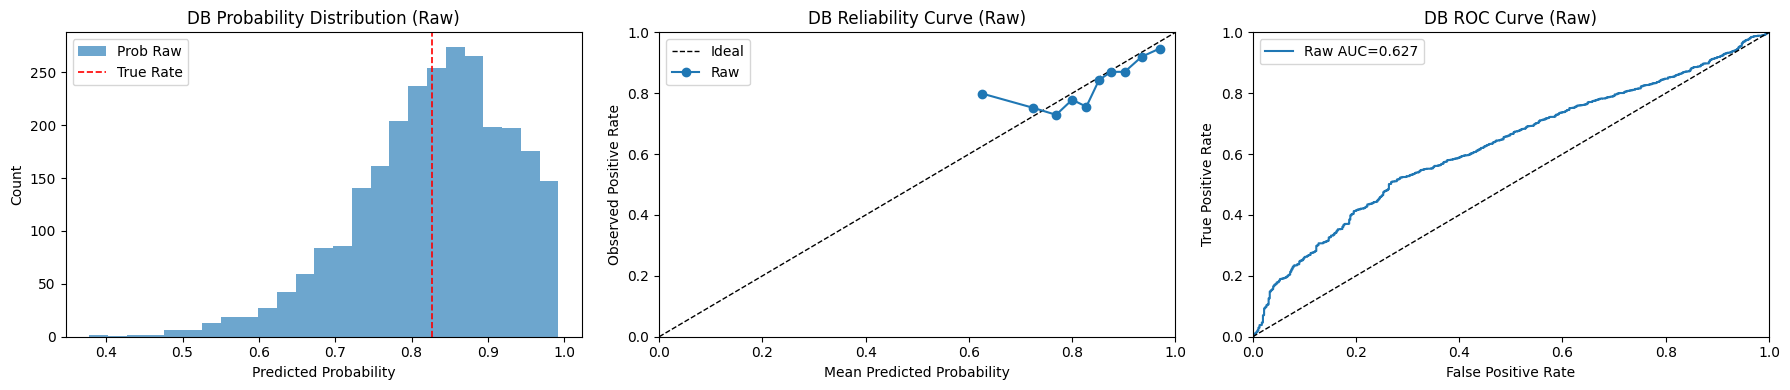

Top 10 contribution probability (raw) — DB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
1943,201800064,Anthony Cook,2018,CB,0.9682,0.992322,1,70.7768
1945,201800071,Josh Proctor,2018,S,0.9640,0.990788,1,68.6475
2568,201900045,Lewis Cine,2019,S,0.9765,0.990121,1,64.0867
1931,201800021,Tyreke Johnson,2018,S,0.9876,0.989861,1,49.1978
6,201500044,Deionte Thompson,2015,S,0.9806,0.989513,1,75.6096
3227,202000035,Demorie Tate,2020,CB,0.9828,0.989308,0,0.0
2599,201900192,Chris Adimora,2019,S,0.9218,0.988612,1,65.0633
2595,201900164,Jeremiah Criddell,2019,S,0.9326,0.987187,1,50.1323
1934,201800032,Isaac Taylor-Stuart,2018,CB,0.9827,0.986657,1,58.414
3828,202100072,Nyland Green,2021,CB,0.9682,0.985642,1,67.105



===== EDGE Classifier Diagnostics (Raw) =====


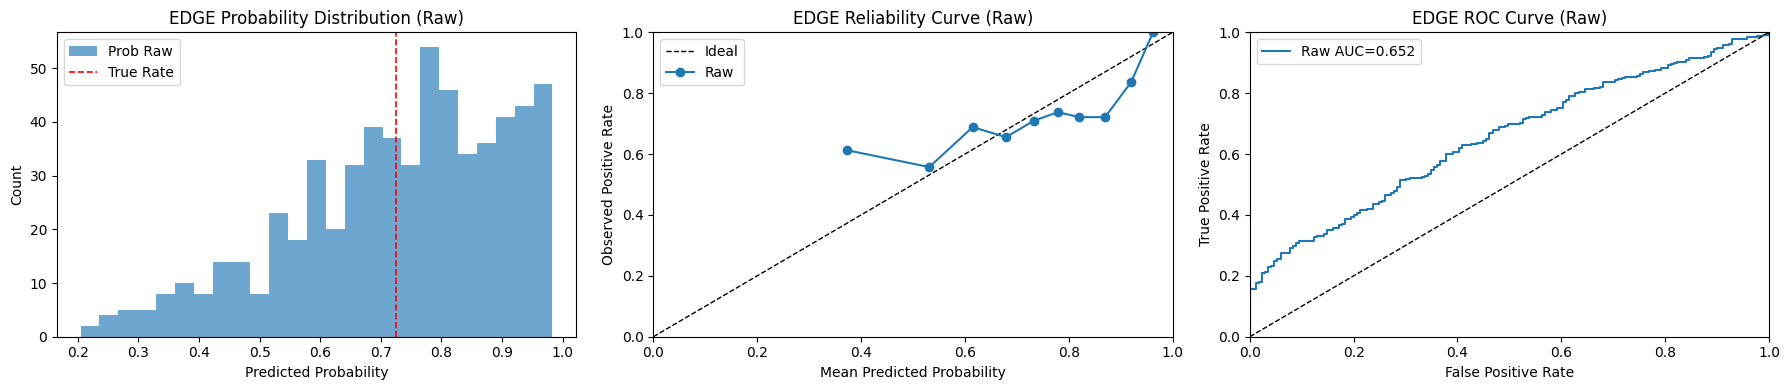

Top 10 contribution probability (raw) — EDGE


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
691,201700167,Jordan Williams,2017,WDE,0.9299,0.983171,1,40.1214
679,201700027,A.J. Epenesa,2017,SDE,0.9868,0.982840,1,87.7959
1817,202000007,Myles Murphy,2020,SDE,0.9965,0.981839,1,77.4651
1082,201800142,Justin Mascoll,2018,WDE,0.9412,0.980692,1,62.3256
7,201500065,Jonathan Ledbetter,2015,SDE,0.9680,0.979332,1,61.0535
325,201600102,Auston Robertson,2016,WDE,0.9521,0.978666,1,38.5664
686,201700128,Addison Gumbs,2017,WDE,0.9407,0.975443,1,32.3989
692,201700175,Jake Lawler,2017,WDE,0.9277,0.975283,1,25.1632
694,201700197,Yetur Gross-Matos,2017,SDE,0.9223,0.975233,1,83.2674
1833,202000177,Van Fillinger,2020,SDE,0.9276,0.973586,1,76.1175



===== IDL Classifier Diagnostics (Raw) =====


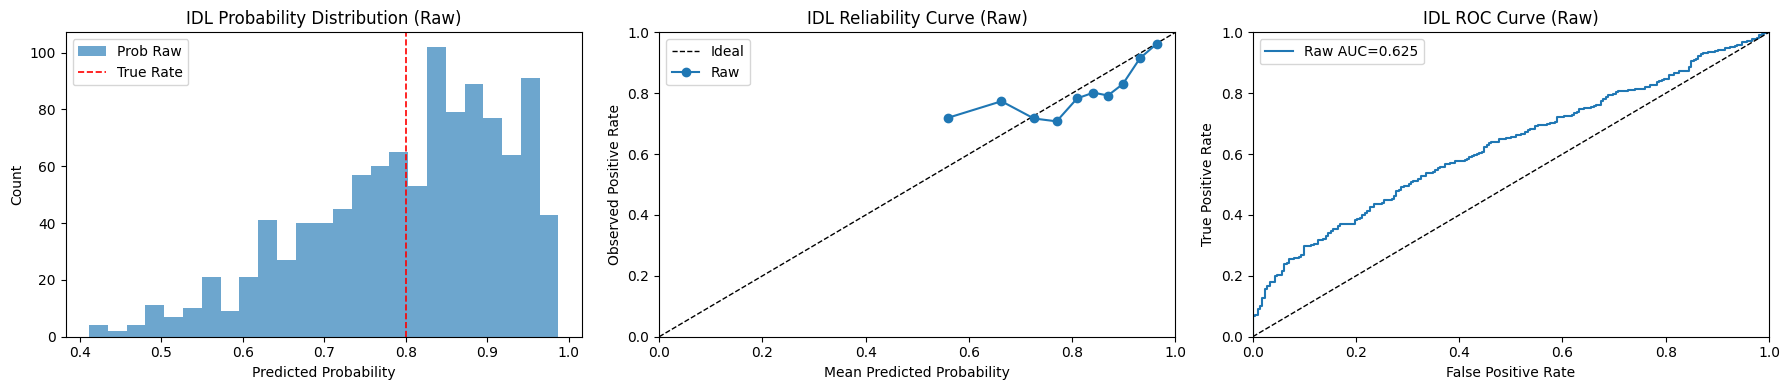

Top 10 contribution probability (raw) — IDL


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
461,201700060,Marlon Tuipulotu,2017,DT,0.9720,0.987303,1,69.904
462,201700068,Haskell Garrett,2017,DT,0.9678,0.985660,1,66.3884
1428,202100022,Shemar Turner,2021,DL,0.9877,0.983302,1,71.1385
711,201800054,Nesta Jade Silvera,2018,DT,0.9730,0.981040,1,63.9221
1423,202100002,Korey Foreman,2021,DL,0.9992,0.980473,1,57.2233
460,201700054,Tyler Shelvin,2017,DT,0.9754,0.980169,1,51.142
225,201600001,Rashan Gary,2016,DT,1.0000,0.980029,1,77.5369
459,201700039,Jay Tufele,2017,DT,0.9817,0.979892,1,70.4798
1439,202100117,Gabriel Rubio,2021,DL,0.9472,0.979888,1,61.7666
712,201800055,Tommy Togiai,2018,DT,0.9721,0.979642,1,59.9642



===== LB Classifier Diagnostics (Raw) =====


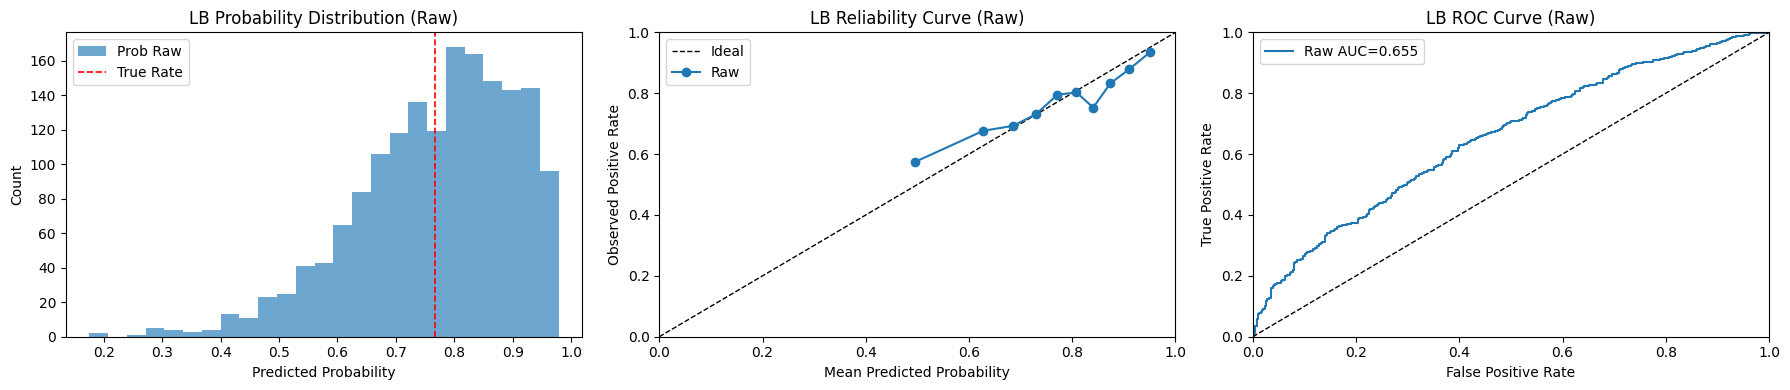

Top 10 contribution probability (raw) — LB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
859,201700136,Jaden Hunter,2017,OLB,0.9379,0.978441,1,51.8126
1397,201800325,Chris Oats,2018,OLB,0.8964,0.976741,1,54.3564
10,201500133,Josh Barajas,2015,OLB,0.9413,0.976198,0,0.0
848,201700061,Jacob Phillips,2017,ILB,0.9719,0.975795,1,60.0596
855,201700100,Markail Benton,2017,OLB,0.9532,0.974516,1,52.019
1361,201800018,Adam Anderson,2018,OLB,0.9889,0.973379,1,70.3671
851,201700078,VanDarius Cowan,2017,OLB,0.9627,0.971618,1,58.0754
1377,201800166,Dallas Gant,2018,OLB,0.9322,0.969779,1,65.1211
1365,201800079,Payton Wilson,2018,OLB,0.9613,0.969772,1,90.1683
2280,202000057,Phillip Webb,2020,OLB,0.9725,0.969403,1,27.435



===== OL Classifier Diagnostics (Raw) =====


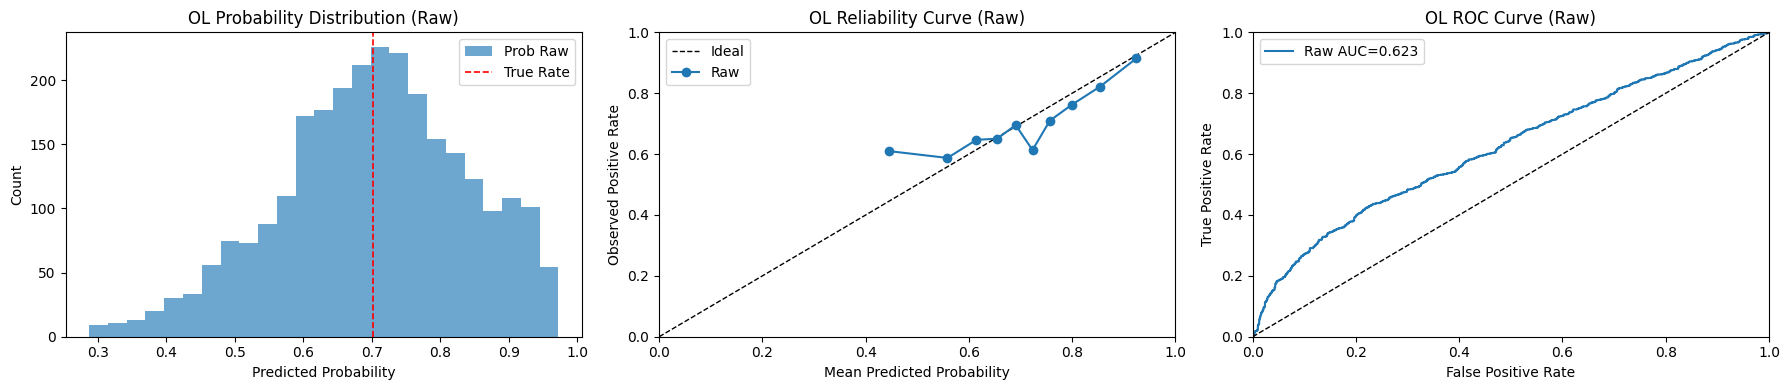

Top 10 contribution probability (raw) — OL


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
2976,202000060,Sedrick Van Pran,2020,OC,0.9712,0.972498,1,74.174
3603,202100124,Ben Christman,2021,IOL,0.9437,0.971229,1,37.0533
2989,202000114,Myles Murao,2020,OC,0.9496,0.970808,1,49.0859
7,201500062,Richie Petitbon,2015,OG,0.9696,0.968864,1,56.3313
3589,202100019,Donovan Jackson,2021,IOL,0.9900,0.967304,1,79.4449
600,201600086,Michael Onwenu,2016,OG,0.9571,0.965981,0,0.0
2388,201900074,Sean Rhyan,2019,OG,0.9671,0.964747,1,61.9733
2990,202000119,Chris Morris,2020,OG,0.9482,0.964511,0,0.0
593,201600039,Ben Bredeson,2016,OT,0.9798,0.964265,1,71.0645
1181,201700087,Netori Johnson,2017,OG,0.9588,0.964055,1,51.6896



===== QB Classifier Diagnostics (Raw) =====


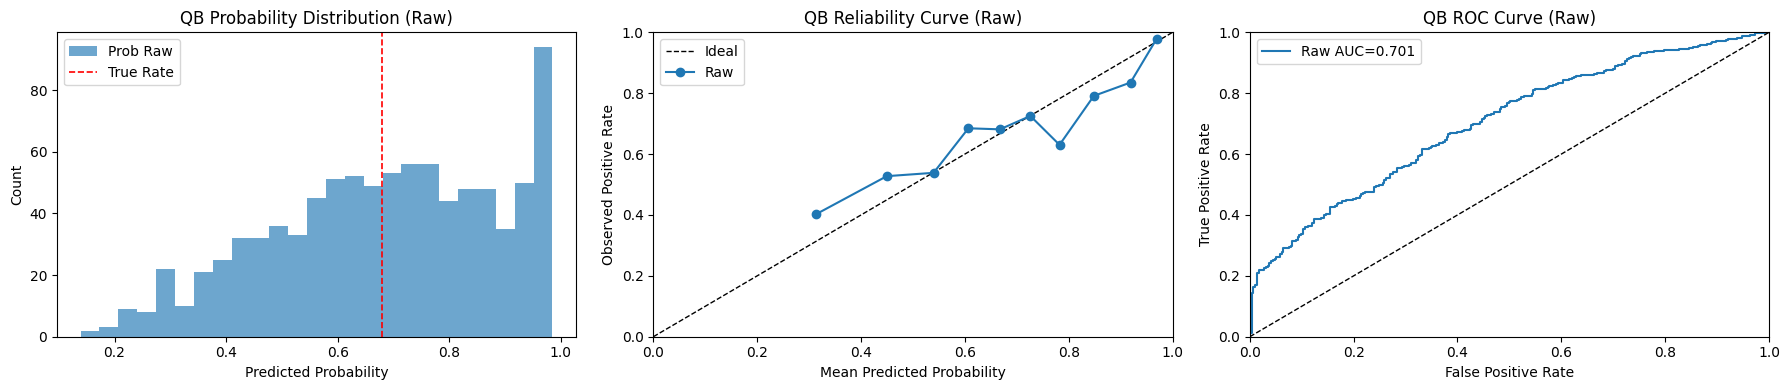

Top 10 contribution probability (raw) — QB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
222,201600061,Brandon Peters,2016,PRO,0.9684,0.984915,1,65.6103
1,201500022,Blake Barnett,2015,PRO,0.9898,0.983984,1,58.2901
764,201800171,Spencer Sanders,2018,DUAL,0.9311,0.983583,1,81.9149
761,201800139,Adrian Martinez,2018,DUAL,0.9423,0.982570,1,83.4854
501,201700152,Myles Brennan,2017,PRO,0.9347,0.981335,1,56.821
224,201600091,Dwayne Haskins,2016,PRO,0.9561,0.980390,1,74.8148
1272,202000059,Hudson Card,2020,DUAL,0.9721,0.980323,1,71.7284
999,201900011,Spencer Rattler,2019,PRO,0.9942,0.979884,1,79.2527
10,201500102,Travis Jonsen,2015,DUAL,0.9529,0.979525,0,0.0
759,201800091,Colson Yankoff,2018,DUAL,0.9564,0.978778,1,32.1109



===== RB Classifier Diagnostics (Raw) =====


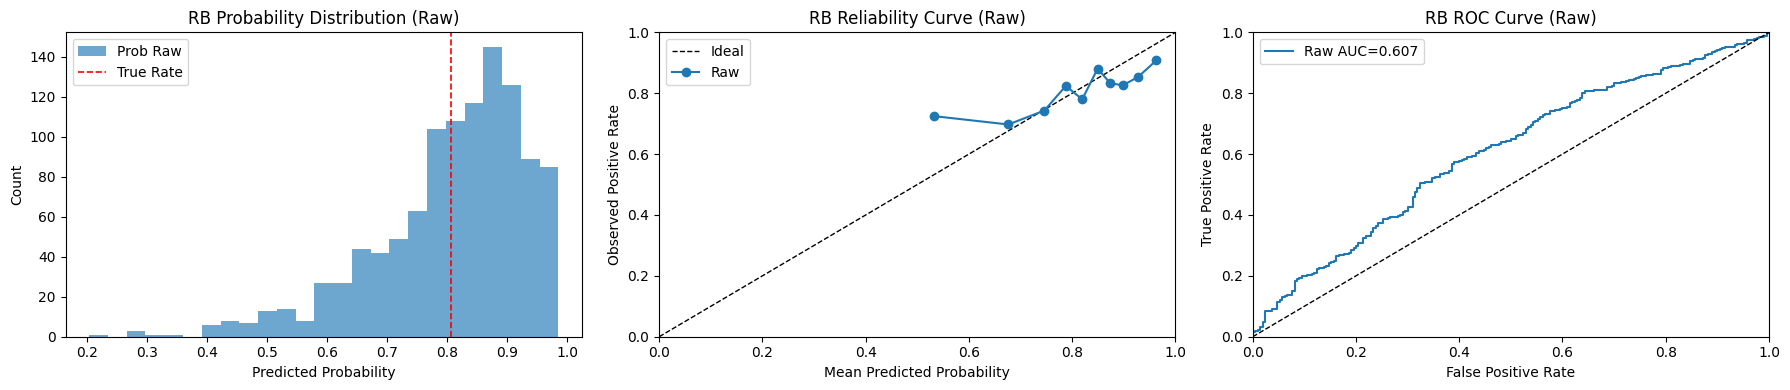

Top 10 contribution probability (raw) — RB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
1037,201800173,Cam'Ron Harris,2018,RB,0.9308,0.985300,1,65.9791
1665,202000077,Roydell Williams,2020,RB,0.9650,0.983278,1,62.9253
686,201700029,Khalan Laborn,2017,APB,0.9866,0.981393,1,55.1993
1676,202000173,Shaadie Clayton-Johnson,2020,RB,0.9280,0.981096,1,52.3221
1669,202000125,Daniyel Ngata,2020,APB,0.9464,0.980316,1,53.0395
684,201700003,Cam Akers,2017,RB,0.9983,0.979669,1,77.3351
1343,201900119,Austin Jones,2019,RB,0.9471,0.978706,1,79.9567
701,201700214,Nathan Tilford,2017,RB,0.9176,0.978688,1,53.2696
1659,202000040,Tank Bigsby,2020,RB,0.9814,0.978513,1,79.4569
14,201500119,Saquon Barkley,2015,RB,0.9458,0.977849,1,87.9078



===== SPEC Classifier Diagnostics (Raw) =====


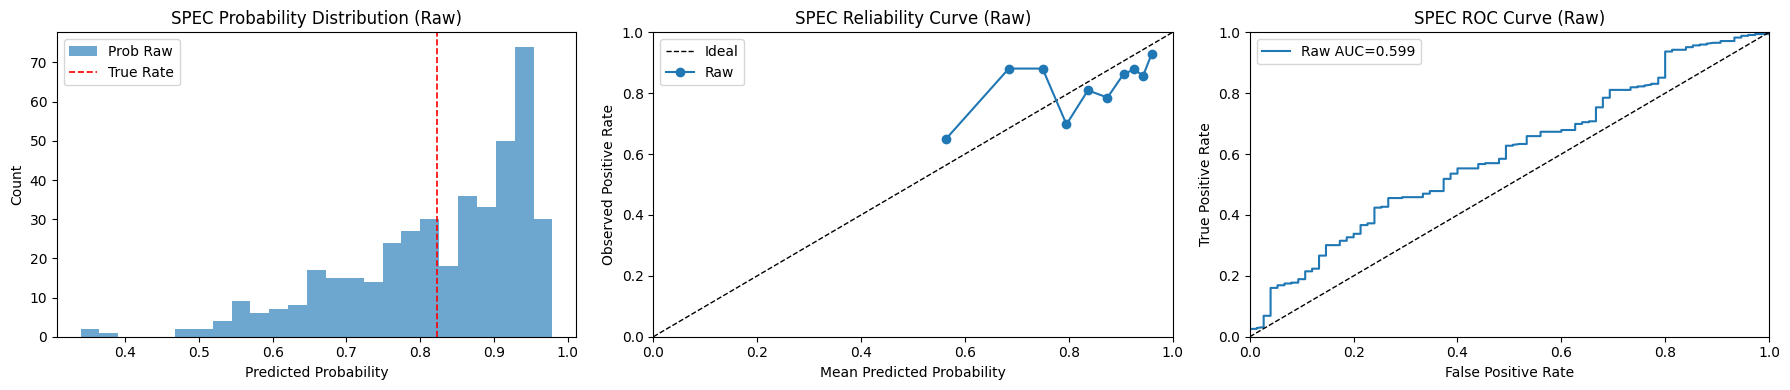

Top 10 contribution probability (raw) — SPEC


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
317,201901893,Tom Hutton,2019,P,0.8250,0.979538,1,57.935
100,201601810,Van Soderberg,2016,K,0.8131,0.972090,1,30.1865
320,201901910,Ivan Mora,2019,K,0.8237,0.971786,1,59.4389
159,201701524,Cole Hahn,2017,K,0.8250,0.970722,1,51.8708
323,201902085,Alan Orona,2019,K,0.8167,0.970666,1,29.4662
5,201501458,Alex Kinney,2015,P,0.8308,0.969297,1,58.594
252,201801853,Nick Mihalic,2018,P,0.8174,0.968799,1,57.1037
10,201501724,Drew Galitz,2015,P,0.8167,0.968112,1,56.4115
90,201601579,Alex Barbir,2016,K,0.8233,0.966459,1,58.7569
1,201500871,Charlie Beall,2015,K,0.8533,0.965391,0,0.0



===== TE Classifier Diagnostics (Raw) =====


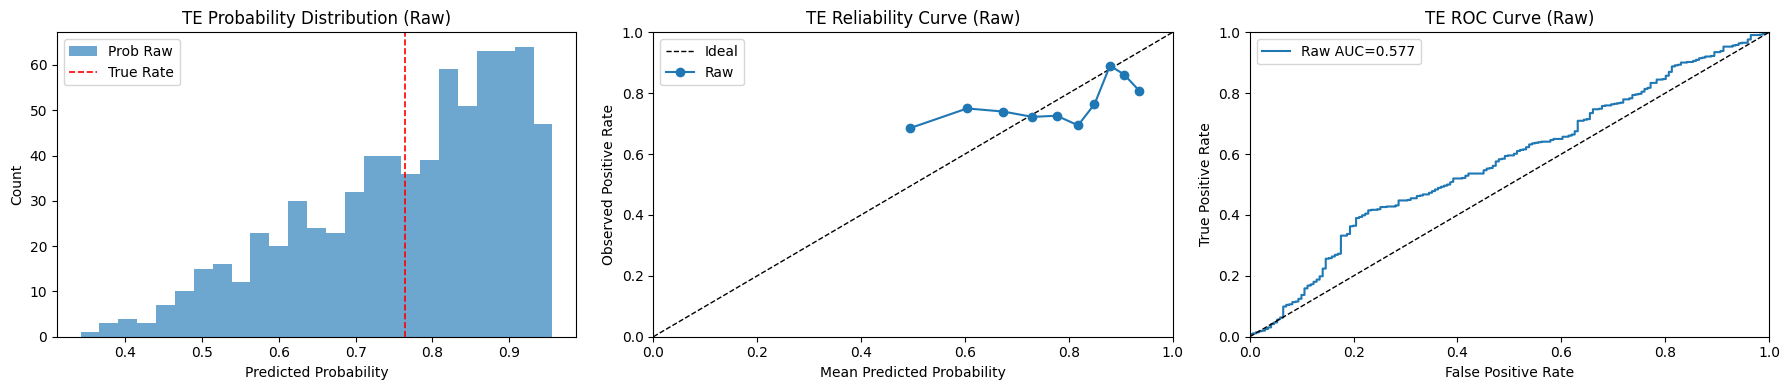

Top 10 contribution probability (raw) — TE


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
700,201901148,Luke Baker,2019,TE,0.8522,0.956676,1,37.6445
345,201700809,Austin Allen,2017,TE,0.8539,0.954288,1,67.7792
695,201901051,Niko Hea,2019,TE,0.8556,0.952627,1,60.1076
183,201600672,Jordan Wilson,2016,TE,0.8603,0.952080,1,67.932
352,201700992,Lou Dorsey,2017,TE,0.8469,0.950710,1,70.8122
689,201900883,Sam Snyder,2019,TE,0.8637,0.949878,0,0.0
1025,202100932,Treylan Davis,2021,TE,0.8596,0.949741,1,64.2228
519,201800648,Bralen Taylor,2018,TE,0.8689,0.948177,0,0.0
1033,202101132,Charlie Browder,2021,TE,0.8522,0.948025,1,44.5686
864,202001180,Trevor Kardell,2020,TE,0.8511,0.947991,1,68.6307



===== WR Classifier Diagnostics (Raw) =====


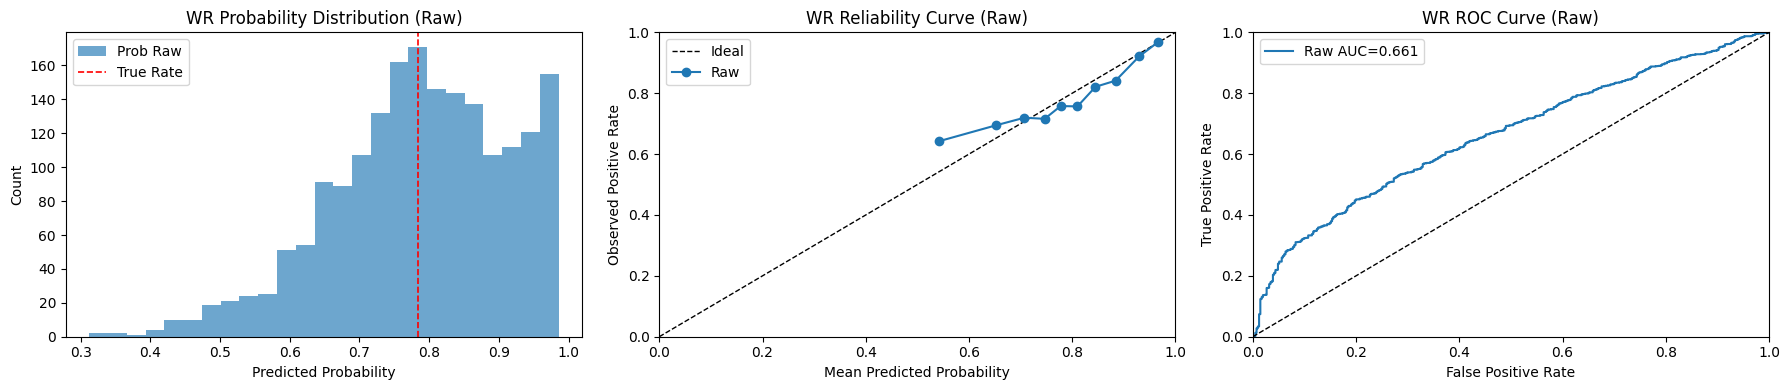

Top 10 contribution probability (raw) — WR


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
2573,202000025,Demond Demas,2020,WR,0.9890,0.985661,1,46.2725
2597,202000157,Jaquavion Fraziars,2020,WR,0.9317,0.984727,1,58.04
2600,202000169,J.J. Evans,2020,WR,0.9285,0.982830,0,0.0
1552,201800127,Jalen Hall,2018,WR,0.9454,0.982805,0,0.0
2607,202000210,KeAndre Lambert-Smith,2020,WR,0.9198,0.982425,1,88.043
1544,201800082,Kevin Austin,2018,WR,0.9601,0.981919,1,64.6201
1545,201800084,Ja'Marr Chase,2018,WR,0.9589,0.981398,1,82.1165
1566,201800192,Jahan Dotson,2018,WR,0.9228,0.981346,1,83.9625
3086,202100079,Chris Hilton Jr.,2021,WR,0.9646,0.981124,1,62.0754
1542,201800069,Jacob Copeland,2018,WR,0.9651,0.980606,1,71.3691


In [13]:
# Classifier visual diagnostics: raw probabilities, reliability, ROC, top raw odds
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

for pos in FINAL_POSITION_GROUPS:
    pred_df = class_prediction_tables.get(pos)
    if pred_df is None or pred_df.empty:
        print(f"\n[{pos}] No classifier prediction table available.")
        continue

    vis_df = pred_df.copy()
    vis_df["y_true_binary"] = pd.to_numeric(vis_df["y_true_binary"], errors="coerce")
    vis_df["y_pred_prob_raw"] = pd.to_numeric(vis_df["y_pred_prob_raw"], errors="coerce")
    vis_df = vis_df.dropna(subset=["y_true_binary", "y_pred_prob_raw"]).copy()

    if vis_df.empty:
        print(f"\n[{pos}] No valid classifier rows for visualization.")
        continue

    print(f"\n===== {pos} Classifier Diagnostics (Raw) =====")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(vis_df["y_pred_prob_raw"], bins=25, alpha=0.65, label="Prob Raw")
    axes[0].axvline(vis_df["y_true_binary"].mean(), color="red", linestyle="--", linewidth=1.2, label="True Rate")
    axes[0].set_title(f"{pos} Probability Distribution (Raw)")
    axes[0].set_xlabel("Predicted Probability")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    def reliability_points(df_in: pd.DataFrame, prob_col: str, bins: int = 10):
        temp = df_in[["y_true_binary", prob_col]].copy()
        temp["bin"] = pd.qcut(temp[prob_col], q=bins, labels=False, duplicates="drop")
        grouped = temp.groupby("bin", observed=True).agg(
            mean_prob=(prob_col, "mean"),
            true_rate=("y_true_binary", "mean"),
            n=("y_true_binary", "size")
        ).reset_index(drop=True)
        return grouped

    rel_raw = reliability_points(vis_df, "y_pred_prob_raw")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=1.0, label="Ideal")
    axes[1].plot(rel_raw["mean_prob"], rel_raw["true_rate"], marker="o", label="Raw")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"{pos} Reliability Curve (Raw)")
    axes[1].set_xlabel("Mean Predicted Probability")
    axes[1].set_ylabel("Observed Positive Rate")
    axes[1].legend()

    if vis_df["y_true_binary"].nunique() > 1:
        fpr_raw, tpr_raw, _ = roc_curve(vis_df["y_true_binary"], vis_df["y_pred_prob_raw"])
        auc_raw = auc(fpr_raw, tpr_raw)
        axes[2].plot(fpr_raw, tpr_raw, label=f"Raw AUC={auc_raw:.3f}")
        axes[2].plot([0, 1], [0, 1], "k--", linewidth=1.0)
        axes[2].set_xlim(0, 1)
        axes[2].set_ylim(0, 1)
        axes[2].set_title(f"{pos} ROC Curve (Raw)")
        axes[2].set_xlabel("False Positive Rate")
        axes[2].set_ylabel("True Positive Rate")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "ROC unavailable\n(single class)", ha="center", va="center")
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

    top_cols = [
        c for c in [
            "player_id", "name", "year", "position", "rating",
            "y_pred_prob_raw", "y_true_binary", "target_career_score_0_100"
        ] if c in vis_df.columns
    ]
    top10 = vis_df.sort_values("y_pred_prob_raw", ascending=False).head(10)
    print(f"Top 10 contribution probability (raw) — {pos}")
    display(top10[top_cols])

In [14]:
# Classifier future predictions: top raw odds by position (2022-2028)
for pos in FINAL_POSITION_GROUPS:
    future_df = class_future_prediction_tables.get(pos)
    if future_df is None or future_df.empty:
        print(f"\n[{pos}] No future classifier predictions available.")
        continue

    out_df = future_df.copy()
    out_df["contrib_prob_raw"] = pd.to_numeric(out_df["contrib_prob_raw"], errors="coerce")
    out_df["contrib_odds_raw"] = pd.to_numeric(out_df["contrib_odds_raw"], errors="coerce")
    out_df = out_df.dropna(subset=["contrib_prob_raw", "contrib_odds_raw"])

    print(f"\nTop future contribution odds (raw) — {pos}")
    display_cols = [
        c for c in [
            "player_id", "name", "year", "position", "rating",
            "contrib_prob_raw", "contrib_odds_raw"
        ] if c in out_df.columns
    ]
    display(out_df.sort_values("contrib_odds_raw", ascending=False).head(10)[display_cols])


Top future contribution odds (raw) — DB


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
6162,202600056,Zyan Gibson,2026,CB,0.9744,0.984882,65.148132
4614,202300039,A.J. Harris,2023,CB,0.9808,0.984825,64.897148
5609,202500063,AnQuon Fegans,2025,S,0.9674,0.984716,64.429680
4288,202200117,Tre'Quon Fegans,2022,CB,0.9530,0.984419,63.181419
4290,202200125,BJ Allen Jr.,2022,S,0.9505,0.983823,60.814796
4612,202300027,Dezz Ricks,2023,CB,0.9846,0.983246,58.688614
4998,202400012,Jaylen Mbakwe,2024,CB,0.9943,0.983088,58.129044
5004,202400037,Xavier Filsaime,2024,S,0.9835,0.982786,57.092251
4611,202300021,Peyton Bowen,2023,S,0.9864,0.982553,56.315285
5598,202500013,Na'eem Offord,2025,CB,0.9936,0.982415,55.867870



Top future contribution odds (raw) — EDGE


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
2826,202500118,Chase Linton,2025,Edge,0.9445,0.985226,66.688004
2413,202300192,AJ Green,2023,Edge,0.9254,0.985071,65.982399
2410,202300127,Chandavian Bradley,2023,Edge,0.9436,0.982889,57.443554
3377,202800072,Jayden Bell,2028,Edge,0.9368,0.982362,55.694530
2587,202400241,CJ Jackson,2024,Edge,0.9148,0.981747,53.784176
3107,202600158,Khamari Brooks,2026,Edge,0.9331,0.981113,51.945347
3101,202600120,Tristian Givens,2026,Edge,0.9475,0.980556,50.429302
2404,202300085,Caleb Herring,2023,Edge,0.9584,0.980522,50.340542
3323,202700186,Myles Smith,2027,Edge,0.9281,0.980239,49.604813
3315,202700090,Zane Rowe,2027,Edge,0.9607,0.979228,47.141773



Top future contribution odds (raw) — IDL


...

,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
560,202302153,Mitch Lake,2023,P,0.8144,0.973643,36.940678
674,202602618,Jimmy Gregg,2026,P,0.8322,0.971784,34.440952
586,202402586,Lucas Osada,2024,P,0.8186,0.970526,32.927979
576,202402351,Kanyon Floyd,2024,P,0.8267,0.967184,29.472614
514,202201725,Will Bettridge,2022,K,0.8300,0.965286,27.807230
520,202201799,Alex Bacchetta,2022,P,0.8259,0.965155,27.698723
546,202301408,Tyler White,2023,P,0.8500,0.964019,26.792446
529,202201912,John Love,2022,K,0.8181,0.963749,26.585756
511,202201537,Alex McPherson,2022,K,0.8378,0.963704,26.551102
675,202602621,Tommy Bauchiero,2026,K,0.8317,0.963704,26.551102



Top future contribution odds (raw) — TE


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
1297,202301316,Will Anciaux,2023,TE,0.8531,0.955035,21.239506
1595,202501309,Austin Simmons,2025,TE,0.8608,0.954788,21.118181
1397,202400775,Noah Onyia,2024,TE,0.8750,0.953724,20.609514
1773,202600890,ArMari Towns,2026,TE,0.8744,0.953449,20.481958
1271,202300688,Jackson Carver,2023,TE,0.8769,0.953449,20.481958
1620,202501684,Tucker Kelleher,2025,TE,0.8517,0.953155,20.346825
1434,202401520,Monte Keener,2024,TE,0.8525,0.952874,20.219658
1289,202301109,Ben Marshall,2023,TE,0.8606,0.952781,20.177738
1596,202501311,Dylan Sims,2025,TE,0.8608,0.952672,20.129356
1300,202301384,Logan Blake,2023,TE,0.8508,0.952669,20.127867



Top future contribution odds (raw) — WR


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
3678,202300082,Ayden Williams,2023,WR,0.9593,0.985269,66.885201
3413,202200078,Kobe Prentice,2022,WR,0.9687,0.984922,65.323593
5360,202800120,Jacolby Campbell,2028,WR,0.9259,0.984885,65.157257
3676,202300078,Shelton Sampson Jr.,2023,WR,0.9610,0.984858,65.042671
4827,202600095,Jase Mathews,2026,WR,0.9575,0.984382,63.030045
3407,202200054,Kevin Coleman Jr.,2022,WR,0.9773,0.984047,61.685055
3679,202300095,Tyler Williams,2023,WR,0.9532,0.983896,61.096439
3415,202200088,Kyion Grayes,2022,WR,0.9627,0.983699,60.346691
3977,202400067,Ny Carr,2024,WR,0.9686,0.983588,59.930954
4816,202600011,Tristen Keys,2026,WR,0.9936,0.983431,59.351868


In [15]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances

# Ignore warnings for binary flag casting
warnings.filterwarnings("ignore", category=UserWarning)

def get_player_comparables(
    target_player_id, 
    df_pool, 
    skill_cols, 
    flag_cols, 
    top_n=5,
    weights={"rating": 3.0, "size": 2.5, "skills": 1.0, "flags": 2.0, "state": 0.5}
):
    """
    Finds similarity within same position but ONLY among PRIOR recruiting classes.
    """
    # 0. Ensure IDs are strings for matching
    df_pool = df_pool.copy()
    df_pool['player_id'] = df_pool['player_id'].astype(str)
    target_id_str = str(target_player_id)
    
    # Check if target exists in pool
    if target_id_str not in df_pool['player_id'].values:
        raise ValueError(f"Player ID {target_id_str} not found in the provided dataset pool. Double check if this player is in a position group that has been loaded.")
        
    target_row = df_pool[df_pool['player_id'] == target_id_str].iloc[0]
    target_year = int(target_row['year'])
    target_pos = target_row['position']
    target_state = target_row['state']

    # 1. Filter for same position and PRIOR years
    df_comps = df_pool[
        (df_pool['position'] == target_pos) & 
        (pd.to_numeric(df_pool['year'], errors='coerce') < target_year)
    ].copy()
    
    if df_comps.empty:
        print(f"⚠️ No matches found in position {target_pos} from years prior to {target_year}.")
        return pd.DataFrame()

    # Prepend target player to the dataframe (idx 0)
    df = pd.concat([pd.DataFrame([target_row]), df_comps], ignore_index=True)
    target_idx = 0
    
    # Helper to safely scale and compute similarity
    def calculate_sim(data_df, weight_key):
        if data_df.empty or weights.get(weight_key, 0) == 0:
            return np.ones(len(df))
        
        # Squeeze out potential objects/strings by forcing numeric first
        data_df_numeric = data_df.apply(pd.to_numeric, errors='coerce')
        
        # Drop columns that are entirely NaNs (prevents mean() and scaler errors)
        data_df_numeric = data_df_numeric.dropna(axis=1, how='all')
        
        if data_df_numeric.empty:
            return np.ones(len(df))
            
        # Fill NaNs: try column mean, then fallback to 0
        mean_vals = data_df_numeric.mean()
        filled_data = data_df_numeric.fillna(mean_vals).fillna(0)
        
        # Scale to 0-1
        scaler = MinMaxScaler()
        try:
            scaled_vals = scaler.fit_transform(filled_data)
        except Exception:
            return np.ones(len(df))
        
        # Compute distance to target_idx
        target_vec = scaled_vals[target_idx]
        dists = np.linalg.norm(scaled_vals - target_vec, axis=1)
        
        # Convert to similarity: 1 - (dist / max_possible_dist)
        max_dist = np.sqrt(data_df_numeric.shape[1])
        sim = 1.0 - (dists / max_dist) if max_dist > 0 else np.ones(len(df))
        return np.nan_to_num(sim, nan=0.0)

    # ---------------------------------------------------------
    # 1. RATING SIMILARITY
    # ---------------------------------------------------------
    rating_sim = calculate_sim(df[['rating']], "rating")
    
    # ---------------------------------------------------------
    # 2. SIZE SIMILARITY
    # ---------------------------------------------------------
    size_cols = ['height_inches', 'weight_lbs']
    size_sim = calculate_sim(df[size_cols], "size")
    
    # ---------------------------------------------------------
    # 3. SKILL SIMILARITY
    # ---------------------------------------------------------
    active_skills = [c for c in skill_cols if c in df.columns]
    skill_sim = calculate_sim(df[active_skills], "skills") if active_skills else np.ones(len(df))
        
    # ---------------------------------------------------------
    # 4. FLAG SIMILARITY (Jaccard)
    # ---------------------------------------------------------
    active_flags = [c for c in flag_cols if c in df.columns]
    if active_flags and weights.get("flags", 0) > 0:
        flags_data = df[active_flags].fillna(0).astype(bool).values
        jaccard_dists = pairwise_distances(flags_data, flags_data[target_idx : target_idx + 1], metric='jaccard').flatten()
        flag_sim = 1.0 - np.nan_to_num(jaccard_dists, nan=1.0)
    else:
        flag_sim = np.ones(len(df))
        
    # ---------------------------------------------------------
    # 5. STATE MATCH SIMILARITY
    # ---------------------------------------------------------
    if pd.isna(target_state) or target_state == "" or weights.get("state", 0) == 0:
        state_sim = np.zeros(len(df))
    else:
        state_sim = (df['state'] == target_state).astype(float).values
        
    # ---------------------------------------------------------
    # 6. BLEND INTO FINAL SIMILARITY SCORE
    # ---------------------------------------------------------
    total_weight = sum(weights.values())
    
    final_sim_score = (
        (rating_sim * weights["rating"]) +
        (size_sim * weights["size"]) +
        (skill_sim * weights["skills"]) +
        (flag_sim * weights["flags"]) +
        (state_sim * weights["state"])
    ) / total_weight
    
    df['similarity_score'] = np.round(final_sim_score * 100, 2)
    
    # ---------------------------------------------------------
    # 7. FORMAT AND RETURN RESULTS
    # ---------------------------------------------------------
    comps = df.drop(index=target_idx).sort_values('similarity_score', ascending=False).head(top_n)
    
    display_cols = [
        'player_id', 'name', 'year', 'similarity_score', 
        'rating', 'height_inches', 'weight_lbs', 'state'
    ]
    
    print(f"🎯 Target Player: {target_row['name']} ({target_row['year']}) | Rating: {target_row['rating']} | {target_row['height_inches']}\" / {target_row['weight_lbs']} lbs | {target_state}")
    print(f"Searching for historical comparables from classes prior to {target_year}... ({len(df_comps)} candidates searched)")
    print("-" * 80)
    
    return comps[display_cols]

# ==========================================
# RE-CONSTRUCT PLAYER UNIVERSE (POOL)
# ==========================================
all_pos_rows = []
for pos, df_pos in datasets.items():
    all_pos_rows.append(df_pos)
for pos, df_future in inference_datasets.items():
    all_pos_rows.append(df_future)

if all_pos_rows:
    player_universe = pd.concat(all_pos_rows, ignore_index=True)
else:
    player_universe = pd.DataFrame()

# Identify feature columns for comparisons
flag_cols = [c for c in player_universe.columns if c.startswith('flag_')]
skill_cols = [c for c in player_universe.columns if c.startswith('skill_')]

# ==========================================
# EXAMPLE USAGE
# ==========================================
target_id = "202600004"
try:
    comps_df = get_player_comparables(target_id, player_universe, skill_cols, flag_cols, top_n=5)
    display(comps_df)
except ValueError as e:
    print(f"❌ Error: {e}")
    if not player_universe.empty:
        print(f"\nExample of available player IDs: {player_universe['player_id'].head(10).tolist()}")
except Exception as e:
    print(f"❌ Unexpected Error: {e}")
    import traceback
    traceback.print_exc()

🎯 Target Player: Jackson Cantwell (2026) | Rating: 0.999 | 79.5" / 325.0 lbs | MO
Searching for historical comparables from classes prior to 2026... (3001 candidates searched)
--------------------------------------------------------------------------------


,player_id,name,year,similarity_score,rating,height_inches,weight_lbs,state
2318,202300010,Kadyn Proctor,2023,92.78,0.9939,79.0,330.0,IA
632,201700009,Walker Little,2017,91.32,0.9952,79.0,315.0,TX
1869,202100008,Amarius Mims,2021,90.84,0.9956,79.0,315.0,GA
630,201700004,Alex Leatherwood,2017,90.39,0.9981,78.0,327.0,FL
631,201700005,Foster Sarell,2017,90.39,0.9968,78.5,311.0,WA
